# Thực hành Bài 07 — Xấp xỉ hàm tuyến tính trên Lunar Lander

Học tăng cường — Học kỳ 1, năm học 2026–2027

Hai bài thực hành trước dùng bảng trên các ô rời rạc: Bài 05 dự đoán giá trị của một chính sách cố định trên $9216$ ô, Bài 06 học điều khiển trên $2187$ ô. Bảng có ba giới hạn đã thấy trong output của hai bài: hai trạng thái liên tục khác nhau rơi vào cùng ô thì nhận cùng giá trị (nhập nhằng), một ô chưa được ghé thì không có ước lượng, và số ô tăng theo tích số khoảng của từng biến. Bài 07 thay bảng bằng hàm có tham số dùng chung. Notebook này dùng hàm tuyến tính theo tham số

$$\hat v(s,w)=x(s)^\top w,\qquad \hat q(s,a,w)=x(s,a)^\top w,$$

trên quan sát liên tục của `LunarLander-v3` (hành động rời rạc, không gió), không rời rạc hóa trạng thái. Phần A (mục 5–9) dự đoán giá trị của cùng chính sách $\pi$ như thực hành Bài 05, nên kết quả so trực tiếp được với bảng $9216$ ô trên cùng dữ liệu. Phần B học điều khiển bằng Sarsa và Q-learning tuyến tính.

**Mục tiêu học tập.** Sau buổi thực hành, sinh viên có thể:

1. xây dựng vector đặc trưng $x(s)$ từ quan sát liên tục (tuyến tính, đa thức, cơ sở Fourier), tính tay một vector đặc trưng và nêu giới hạn biểu diễn của lớp tuyến tính;
2. cài đặt Monte Carlo (MC) tuyến tính và phương pháp sai phân thời gian (TD) một bước TD(0) với cập nhật bán gradient theo đúng quy trình của Bài 07, kiểm tra từng cập nhật bằng phép tính tay;
3. tính nghiệm theo lô của hai phương pháp (hồi quy bình phương tối thiểu cho MC và TD bình phương tối thiểu (LSTD) cho TD) và giải thích vì sao TD hướng tới điểm cố định Bellman chiếu chứ không tới hình chiếu của $v_\pi$;
4. ghép đặc trưng cho cặp trạng thái–hành động, cài đặt Sarsa và Q-learning tuyến tính, theo dõi dấu hiệu bất ổn của bộ ba bất ổn;
5. đánh giá và trực quan hóa các chính sách học được, so với hai mốc và với kết quả dạng bảng của Bài 06.

**Tiên quyết.** Bài 05–06 và hai notebook thực hành tương ứng; Bài 07 (hàm có tham số, mục tiêu cập nhật, MC và TD(0) với hàm xấp xỉ, điểm cố định Bellman chiếu, Sarsa và Q-learning với xấp xỉ hàm). Python cơ bản, NumPy và đại số tuyến tính (tích vô hướng, giải hệ phương trình).

**Cách dùng.** Chạy các ô mã theo thứ tự từ trên xuống. Ô mã cài đặt ở phần 1 tự cài các gói cần thiết, nên notebook chạy được trên Jupyter cục bộ hoặc Google Colab mà không cần tệp nào khác. Mọi phép ngẫu nhiên dùng hạt giống (seed) cố định, nên chạy lại với cùng phiên bản các gói cho cùng số liệu; phiên bản khác có thể cho số liệu lệch. Các mục **Câu hỏi:** có lời giải thu gọn. Toàn bộ notebook chạy khoảng $7$–$8$ phút trên CPU khi soạn (phần lớn là hai lần huấn luyện ở mục 12) và dùng dưới $1$ GB bộ nhớ (đo khi soạn: khoảng $0{,}5$ GB); trên Colab (CPU chậm hơn, khoảng $12$ GB bộ nhớ) có thể mất trên $10$ phút. Tổng thời gian thực được in ở cuối notebook.

**Ký hiệu** (thống nhất với ghi chú Bài 07):

| Ký hiệu, thuật ngữ | Ý nghĩa trong notebook |
| --- | --- |
| lượt | một episode: từ `reset` tới khi kết thúc thật hoặc bị cắt ngắn ở $1000$ bước |
| ô mã | một ô của notebook (để phân biệt với ô rời rạc của Bài 05–06) |
| $o$, $S_t$ | quan sát $8$ chiều; trạng thái tại thời điểm $t$, ở đây chính là quan sát liên tục |
| $\phi(s)\in\mathbb R^p$ | đặc trưng trạng thái do một họ đặc trưng tạo ra (mục 4) |
| $x(s)$, $x(s,a)\in\mathbb R^d$ | vector đặc trưng dùng để dự đoán $\hat v$ (phần A, $x=\phi$) và $\hat q$ (phần B) |
| $w\in\mathbb R^d$, $w_0$ | vector trọng số và giá trị khởi tạo |
| $\hat v(s,w)$, $\hat q(s,a,w)$ | giá trị trạng thái và giá trị hành động ước lượng |
| $G_t$ | lợi tức chiết khấu tính từ thời điểm $t$ |
| $\delta$ | sai lệch giữa mục tiêu cập nhật và dự đoán hiện tại |
| $\alpha$, $c$ | bước học; $\alpha=c/\mathbb E[\lVert x\rVert^2]$ với hằng số $c$ (mục 6) |
| $\bar g(s)$ | $\mathbb E[G_t\mid S_t=s]$ theo phân phối ghé của dữ liệu; bằng $v_\pi(s)$ khi trạng thái có tính Markov (mục 5) |
| $\mu$, $\overline{\mathrm{VE}}(w)$ | phân phối trọng số trên trạng thái và sai số giá trị trung bình $\tfrac12\sum_s\mu(s)(v_\pi(s)-\hat v(s,w))^2$ (mục 6) |
| $\Phi$, $D$ | ma trận đặc trưng (hàng $x(s)^\top$) và ma trận chéo của phân phối ghé; trong bài toán theo lượt, $D$ là phân phối ghé theo lượt thay cho phân phối dừng (mục 8) |
| $P_\pi$, $r_\pi$, $T_\pi$ | ma trận chuyển và vector phần thưởng kỳ vọng theo $\pi$; toán tử Bellman $T_\pi v=r_\pi+\gamma P_\pi v$ |
| $\Pi_D$ | phép chiếu bình phương tối thiểu có trọng số $D$ lên không gian con $\{\Phi w\}$ |
| $\hat A$, $\hat b$ | ước lượng từ dữ liệu của $A$, $b$ trong phương trình điểm cố định $Aw=b$ |
| $J(\hat v)$ | sai số dự đoán lợi tức trên tập kiểm tra (mục 5) |
| $\gamma$ | hệ số chiết khấu, dùng $\gamma=0{,}99$ |
| SE | sai số chuẩn (standard error) của một trung bình mẫu |

## 1. Cài đặt và chuẩn bị

Lệnh `%pip` cài Gymnasium kèm phần mở rộng `box2d` (bộ mô phỏng vật lý Box2D cần cho Lunar Lander), NumPy và Matplotlib. Nếu Gymnasium có sẵn cũ hơn bản 1.0 (có thể gặp trên Colab), `pip` nâng cấp lên bản mới; NumPy và Matplotlib đã có thì giữ nguyên bản sẵn có. Nếu môi trường cục bộ đã cài đủ, có thể bỏ qua ô này.

`pip` có thể in dòng *Note: you may need to restart the kernel to use updated packages*. Khi ô cài đặt được chạy trước mọi lệnh `import`, không cần khởi động lại. Nếu trước đó đã `import` một bản cũ của gói vừa được nâng cấp, cần khởi động lại kernel rồi chạy lại notebook từ đầu. Trên Colab, `pip` có thể in cảnh báo xung đột giữa `pygame` và `pygame-ce`; notebook không dùng chức năng hiển thị của Gymnasium (không gọi `render`), nên có thể bỏ qua cảnh báo này. Box2D được cài từ gói dựng sẵn (wheel) khi có bản phù hợp với phiên bản Python của phiên làm việc; nếu bước cài mất nhiều phút hoặc báo lỗi biên dịch (`swig`), cần kiểm tra phiên bản Python (`import sys; sys.version`) và chọn phiên bản Python có gói dựng sẵn.

In [1]:
%pip install -q "gymnasium[box2d]>=1.0" numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import inspect
import itertools
import time

import numpy as np
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
from gymnasium.envs.box2d import lunar_lander as ll

print("gymnasium", gym.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

T_START = time.time()   # đo tổng thời gian chạy notebook
GAMMA = 0.99            # hệ số chiết khấu
EVAL_SEED = 10_000      # hạt giống các lượt đánh giá hai chính sách tham chiếu (phần 3)
EPS_PI = 0.1            # xác suất chọn hành động ngẫu nhiên của chính sách pi ở phần A (như Bài 05)
DATA_TRAIN_SEED = 20_000  # hạt giống tập huấn luyện của phần A (trùng thực hành Bài 05)
DATA_TEST_SEED = 50_000   # hạt giống tập kiểm tra của phần A (trùng thực hành Bài 05)

gymnasium 1.3.0 | numpy 2.5.3 | matplotlib 3.11.2


## 2. Môi trường Lunar Lander

Một tàu đổ bộ xuất phát phía trên khung hình, chịu một lực đẩy ngẫu nhiên ban đầu và rơi dưới trọng lực; bãi đáp là đoạn nằm ngang giữa hai lá cờ, địa hình hai bên sinh ngẫu nhiên ở mỗi lần `reset`. Môi trường được tạo với `continuous=False` (bốn hành động rời rạc) và `enable_wind=False` (không gió, không nhiễu xoắn).

- **Quan sát** gồm $8$ thành phần: vị trí $x,y$, vận tốc $v_x,v_y$, góc nghiêng $\varphi$, vận tốc góc $\omega$ và hai cờ chân chạm đất $l_1,l_2$.
- **Hành động:** $0$ không bật động cơ, $1$ bật động cơ định hướng bên trái, $2$ bật động cơ chính, $3$ bật động cơ định hướng bên phải.
- **Phần thưởng** ở bước không kết thúc là độ tăng của $\Phi(s)=-100\sqrt{x^2+y^2}-100\sqrt{v_x^2+v_y^2}-100\lvert\varphi\rvert+10l_1+10l_2$ trừ chi phí nhiên liệu ($0{,}3$ cho động cơ chính, $0{,}03$ cho động cơ định hướng). Ở bước kết thúc, phần thưởng là $-100$ nếu thân tàu chạm đất hoặc ra khỏi khung hình ($\lvert x\rvert\ge1$), và $+100$ nếu thân tàu nằm yên, ở bất kỳ vị trí nào; khoảng cách tới bãi đáp chỉ đi vào phần thưởng qua $\Phi$.
- **Cắt ngắn:** lượt dừng ở $1000$ bước nếu chưa kết thúc; trạng thái lúc đó chưa phải trạng thái kết thúc.

Thực hành Bài 05 kiểm công thức phần thưởng trên từng bước; ở đây chỉ in các thông số và đoạn mã tính phần thưởng trong hàm `step` của Gymnasium để đối chiếu.

In [3]:
ENV_ID = "LunarLander-v3"
ENV_KWARGS = dict(continuous=False, enable_wind=False)   # hành động rời rạc, không gió; trọng lực mặc định


def make_env():
    return gym.make(ENV_ID, **ENV_KWARGS)


env = make_env()
core = env.unwrapped                     # đối tượng LunarLander bên trong các lớp bao
obs, _ = env.reset(seed=0)
print("không gian quan sát:", env.observation_space)
print("không gian hành động:", env.action_space)
print("giới hạn số bước mỗi lượt (max_episode_steps):", env.spec.max_episode_steps)
print("gió:", core.enable_wind, "| hành động liên tục:", core.continuous, "| mỗi bước dài", 1 / ll.FPS, "giây")
src = inspect.getsource(ll.LunarLander.step)
start, stop = src.index("shaping = ("), src.index("reward = +100")
print(src[start:stop + len("reward = +100")])

không gian quan sát: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
không gian hành động: Discrete(4)
giới hạn số bước mỗi lượt (max_episode_steps): 1000
gió: False | hành động liên tục: False | mỗi bước dài 0.02 giây
shaping = (
            -100 * np.sqrt(state[0] * state[0] + state[1] * state[1])
            - 100 * np.sqrt(state[2] * state[2] + state[3] * state[3])
            - 100 * abs(state[4])
            + 10 * state[6]
            + 10 * state[7]
        )  # And ten points for legs contact, the idea is if you
        # lose contact again after landing, you get negative reward
        if self.prev_shaping is not None:
            reward = shaping - self.prev_shaping
        self.prev_shaping = shaping

        reward -= (
            m_power * 0.30
        )  # less fuel spent is better, about -30 for heuristic landing
        r

## 3. Đánh giá qua nhiều lượt và hai chính sách tham chiếu

**Vấn đề.** Phần B đánh giá các chính sách học được; phần A cần một chính sách cố định để dự đoán. Cả hai dùng chung một thước đo và hai mốc so sánh. Một lượt chỉ là một mẫu: địa hình, lực đẩy ban đầu và nhiễu của động cơ đổi theo lượt.

**Thước đo.** Hàm `evaluate` chạy $N$ lượt; lượt thứ $i$ dùng hạt giống `seed + i` cho cả `reset` lẫn bộ sinh số ngẫu nhiên của chính sách, nên mọi chính sách gặp cùng dãy địa hình và lực đẩy ban đầu. Mỗi lượt ghi tổng thưởng không chiết khấu $\sum_tR_{t+1}$ (Gymnasium coi lượt đạt tổng thưởng từ $200$ là lời giải), lợi tức chiết khấu $G_0=\sum_t\gamma^tR_{t+1}$, độ dài và cách lượt dừng. Trung bình được báo kèm $\mathrm{SE}=\mathrm{sd}/\sqrt N$, với sd là độ lệch chuẩn mẫu. Hai chính sách $A$, $B$ dùng cùng dãy hạt giống nên lượt thứ $i$ của chúng tạo một cặp; `paired_difference` báo $\bar d\pm1{,}96\,\mathrm{SE}(d)$ với $d_i=\text{tổng thưởng}^A_i-\text{tổng thưởng}^B_i$. Các hàm ở ô mã dưới giống hệt thực hành Bài 06.

**Hai mốc.** Chính sách ngẫu nhiên đều chọn mỗi hành động với xác suất $1/4$. Bộ điều khiển viết tay `heuristic(env, s)` của Gymnasium tính góc nghiêng và độ cao mục tiêu theo vị trí rồi bật động cơ theo phần cần hiệu chỉnh lớn hơn; đây là chính sách tất định do con người thiết kế. Mọi chính sách có cùng giao diện `policy(obs, rng) -> hành động`, với `rng` là bộ sinh số ngẫu nhiên của lượt.

In [4]:
def random_policy(obs, rng):
    return int(rng.integers(4))                       # hành động đều trong {0, 1, 2, 3}


def make_heuristic_policy(env_core):
    def policy(obs, rng):
        return int(ll.heuristic(env_core, obs))       # bộ điều khiển viết tay của Gymnasium, tất định
    return policy


def run_episode(env, policy, seed, keep_terrain=False):
    # Chạy một lượt; lưu quan sát (T+1, 8), hành động (T,), phần thưởng (T,) và cờ dừng
    rng = np.random.default_rng(seed)
    obs, _ = env.reset(seed=seed)
    ep = {"seed": seed}
    if keep_terrain:                                  # địa hình và bãi đáp, chỉ dùng để vẽ
        u = env.unwrapped
        ep["terrain"] = [list(map(float, p[0])) for p in u.sky_polys] + [list(map(float, u.sky_polys[-1][1]))]
        ep["helipad"] = (float(u.helipad_x1), float(u.helipad_x2), float(u.helipad_y))
    states, actions, rewards = [obs], [], []
    while True:
        a = policy(obs, rng)
        obs, r, terminated, truncated, _ = env.step(a)
        states.append(obs); actions.append(a); rewards.append(r)
        if terminated or truncated:
            break
    ep.update(obs=np.array(states), actions=np.array(actions), rewards=np.array(rewards, dtype=float),
              terminated=bool(terminated), truncated=bool(truncated))
    return ep


def outcome(ep):
    # Cách lượt dừng: xét kết thúc thật trước (một lượt có thể vừa kết thúc vừa chạm giới hạn 1000 bước)
    if ep["terminated"]:
        return "nằm yên (+100)" if ep["rewards"][-1] == 100 else "rơi hoặc ra ngoài (-100)"
    return "cắt ngắn 1000 bước"


def discounted_return(rewards, gamma):
    return float(np.sum(rewards * gamma ** np.arange(len(rewards))))   # G_0


def evaluate(env, policy, n_episodes, seed, gamma):
    eps_list = [run_episode(env, policy, seed + i) for i in range(n_episodes)]
    return {"episodes": eps_list, "seeds": [seed + i for i in range(n_episodes)],
            "total": np.array([e["rewards"].sum() for e in eps_list]),               # tổng thưởng không chiết khấu
            "G0": np.array([discounted_return(e["rewards"], gamma) for e in eps_list]),
            "length": np.array([len(e["actions"]) for e in eps_list]),
            "outcome": [outcome(e) for e in eps_list]}


OUTCOMES = ["nằm yên (+100)", "rơi hoặc ra ngoài (-100)", "cắt ngắn 1000 bước"]


def summarize(name, res):
    n = len(res["total"])
    se = lambda v: v.std(ddof=1) / np.sqrt(n)
    frac = "  ".join(f"{k}: {res['outcome'].count(k) / n:4.0%}" for k in OUTCOMES)
    print(f"{name:<26} tổng thưởng {res['total'].mean():7.1f} ± {se(res['total']):4.1f} | "
          f"G_0 {res['G0'].mean():6.1f} ± {se(res['G0']):4.1f} | dài {res['length'].mean():5.0f} bước | {frac}")


def paired_difference(res_a, res_b, key="total"):
    # Hiệu theo cặp d_i = res_a[key][i] - res_b[key][i] trên cùng hạt giống; trả trung bình và 1,96 * SE
    assert res_a["seeds"] == res_b["seeds"]
    d = res_a[key] - res_b[key]
    return d.mean(), 1.96 * d.std(ddof=1) / np.sqrt(len(d))


N_EVAL = 100
baselines = {"ngẫu nhiên": random_policy, "heuristic": make_heuristic_policy(core)}
t0 = time.time()
results_ref = {name: evaluate(env, p, N_EVAL, EVAL_SEED, GAMMA) for name, p in baselines.items()}
print(f"{N_EVAL} lượt mỗi chính sách, cùng tập hạt giống; trung bình ± SE ({time.time() - t0:.1f} giây)")
for name, res in results_ref.items():
    summarize(name, res)
m, h = paired_difference(results_ref["heuristic"], results_ref["ngẫu nhiên"])
print(f"heuristic - ngẫu nhiên, tổng thưởng: {m:6.1f} ± {h:4.1f} (khoảng 95%, ghép cặp)")

100 lượt mỗi chính sách, cùng tập hạt giống; trung bình ± SE (2.1 giây)
ngẫu nhiên                 tổng thưởng  -187.4 ± 10.7 | G_0  -93.6 ±  5.0 | dài    91 bước | nằm yên (+100):   0%  rơi hoặc ra ngoài (-100): 100%  cắt ngắn 1000 bước:   0%
heuristic                  tổng thưởng   255.4 ±  7.5 | G_0   72.9 ±  2.2 | dài   249 bước | nằm yên (+100):  96%  rơi hoặc ra ngoài (-100):   3%  cắt ngắn 1000 bước:   1%
heuristic - ngẫu nhiên, tổng thưởng:  442.8 ± 24.8 (khoảng 95%, ghép cặp)


Biểu đồ dưới vẽ phân bố tổng thưởng của hai mốc trên cùng một bộ khoảng chia.

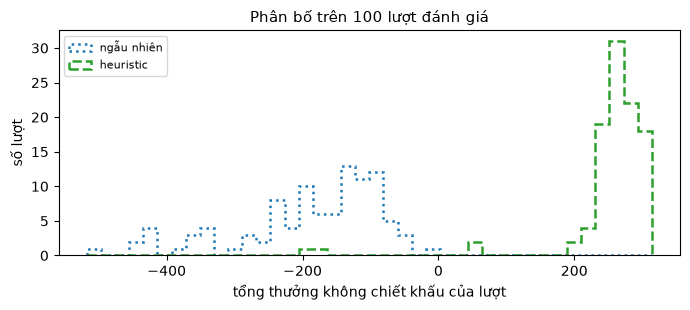

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.2))
allv = np.concatenate([res["total"] for res in results_ref.values()])
bins = np.linspace(allv.min(), allv.max(), 41)                         # chung một bộ khoảng cho hai chính sách
for (name, res), ls, col in zip(results_ref.items(), [":", "--"], ["C0", "C2"]):
    ax.hist(res["total"], bins=bins, histtype="step", linestyle=ls, color=col, linewidth=1.8, label=name)
ax.set_xlabel("tổng thưởng không chiết khấu của lượt"); ax.set_ylabel("số lượt"); ax.legend(fontsize=8)
ax.set_title(f"Phân bố trên {N_EVAL} lượt đánh giá", fontsize=11)
plt.tight_layout()
plt.show()

### 3.1. Trực quan hóa một lượt của hai chính sách tham chiếu

Phần này ghi lại một lượt của mỗi mốc trên cùng hạt giống, nên hai lượt có cùng địa hình và lực đẩy ban đầu. Hạt giống minh họa là hạt giống đầu tiên trong tập đánh giá mà heuristic kết thúc bằng nằm yên; mã kiểm tra lượt ghi lại trùng độ dài với lượt tương ứng trong phép đánh giá. Các hàm vẽ ở đây được dùng lại ở mục 9 (dự đoán) và ở phần B cho chính sách học được.

**Tọa độ vẽ.** Quan sát đã chuẩn hóa được đổi về tọa độ của bộ mô phỏng (mét) theo công thức trong `step`:

$$x_w=\frac W2\,(x+1),\qquad y_w=\frac H2\,y+y_{\text{bãi}}+\frac{\texttt{LEG\_DOWN}}{\texttt{SCALE}},$$

với $W\times H$ là kích thước khung hình ($20\times13{,}3$ m) và $y_{\text{bãi}}$ là độ cao bãi đáp. Thân tàu là đa giác `LANDER_POLY` của mã nguồn, quay góc $\varphi$; hai chân được vẽ gần đúng.

ngẫu nhiên   hạt giống 10000: 66 bước, rơi hoặc ra ngoài (-100), tổng thưởng -129.9
heuristic    hạt giống 10000: 190 bước, nằm yên (+100), tổng thưởng 253.3


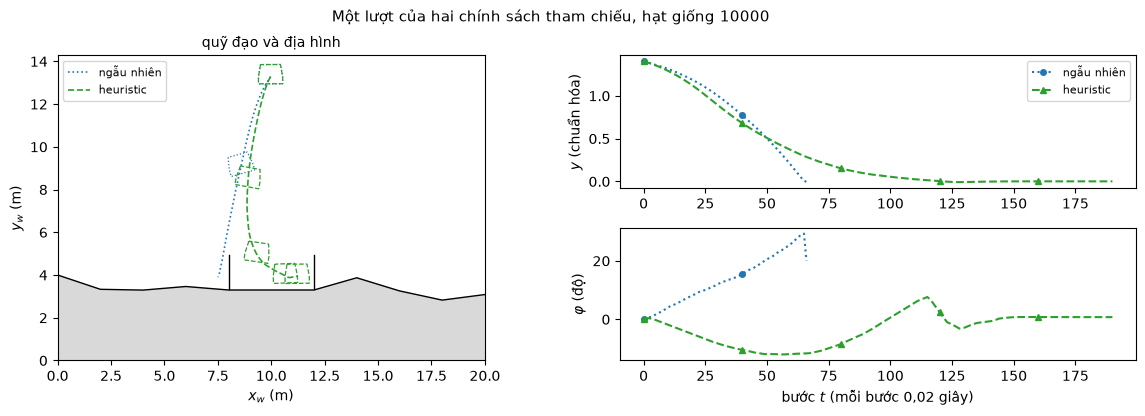

In [6]:
W_WORLD = ll.VIEWPORT_W / ll.SCALE      # bề rộng khung hình (m)
H_WORLD = ll.VIEWPORT_H / ll.SCALE      # chiều cao khung hình (m)
LANDER_POLY = np.array(ll.LANDER_POLY, dtype=float) / ll.SCALE   # đa giác thân tàu trong hệ tọa độ thân (m)


def to_world(obs, helipad_y):
    # Quan sát chuẩn hóa -> tọa độ (m) của tâm thân tàu, theo công thức trong step()
    xw = obs[..., 0] * (W_WORLD / 2) + W_WORLD / 2
    yw = obs[..., 1] * (H_WORLD / 2) + helipad_y + ll.LEG_DOWN / ll.SCALE
    return xw, yw


def lander_outline(xw, yw, phi):
    # Đa giác thân tàu sau khi quay góc phi (ngược chiều kim đồng hồ) và tịnh tiến tới (xw, yw)
    c, s = np.cos(phi), np.sin(phi)
    px, py = LANDER_POLY[:, 0], LANDER_POLY[:, 1]
    return np.c_[xw + c * px - s * py, yw + s * px + c * py]


def plot_episodes(episodes, styles, title, every=40):
    # Trái: quỹ đạo trong mặt phẳng, kèm địa hình và hình thân tàu mỗi `every` bước; phải: y(t) và góc phi(t)
    fig = plt.figure(figsize=(12, 4.2))
    ax0 = fig.add_subplot(1, 2, 1)
    ax1 = fig.add_subplot(2, 2, 2)
    ax2 = fig.add_subplot(2, 2, 4, sharex=ax1)
    first = next(iter(episodes.values()))
    terr = np.array(first["terrain"])
    x1, x2, hy = first["helipad"]
    ax0.fill_between(terr[:, 0], 0, terr[:, 1], color="0.85")
    ax0.plot(terr[:, 0], terr[:, 1], color="k", lw=1)
    for xf in (x1, x2):                                             # hai cờ của bãi đáp
        ax0.plot([xf, xf], [hy, hy + 1.6], color="k", lw=1)
    for name, ep in episodes.items():
        st = styles[name]
        xw, yw = to_world(ep["obs"], hy)
        t = np.arange(len(xw))
        ax0.plot(xw, yw, ls=st["ls"], color=st["color"], lw=1.2, label=name)
        for k in range(0, len(xw), every):                          # hình thân tàu tại một số thời điểm
            ax0.add_patch(plt.Polygon(lander_outline(xw[k], yw[k], ep["obs"][k, 4]), fill=False, ls=st["ls"],
                                      ec=st["color"], lw=0.9))
        ax1.plot(t, ep["obs"][:, 1], ls=st["ls"], color=st["color"], marker=st["marker"], markevery=every, ms=4, label=name)
        ax2.plot(t, np.degrees(ep["obs"][:, 4]), ls=st["ls"], color=st["color"], marker=st["marker"], markevery=every, ms=4)
    y_top = max(H_WORLD, max(to_world(ep["obs"], hy)[1].max() for ep in episodes.values()) + 1.0)
    ax0.set_xlim(0, W_WORLD); ax0.set_ylim(0, y_top); ax0.set_aspect("equal")   # giữ cả phần quỹ đạo trên khung hình
    ax0.set_xlabel("$x_w$ (m)"); ax0.set_ylabel("$y_w$ (m)"); ax0.legend(fontsize=8, loc="upper left")
    ax0.set_title("quỹ đạo và địa hình", fontsize=10)
    ax1.set_ylabel("$y$ (chuẩn hóa)"); ax1.legend(fontsize=8)
    ax2.set_ylabel(r"$\varphi$ (độ)"); ax2.set_xlabel("bước $t$ (mỗi bước 0,02 giây)")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


STYLES = {"ngẫu nhiên": dict(ls=":", marker="o", color="C0"),           # kiểu nét và dấu phân biệt chính sách
          "heuristic": dict(ls="--", marker="^", color="C2"),
          "Sarsa tuyến tính": dict(ls="-", marker="s", color="C1"),
          "Q-learning tuyến tính": dict(ls="-.", marker="x", color="C3")}

# Hạt giống minh họa: lượt đầu tiên trong tập đánh giá mà heuristic kết thúc bằng nằm yên
k_ref = next(i for i, oc in enumerate(results_ref["heuristic"]["outcome"]) if oc == "nằm yên (+100)")
VIZ_SEED_REF = EVAL_SEED + k_ref
episodes_ref = {name: run_episode(env, baselines[name], VIZ_SEED_REF, keep_terrain=True) for name in baselines}
for name, ep in episodes_ref.items():
    assert len(ep["actions"]) == results_ref[name]["length"][k_ref]      # trùng lượt trong phép đánh giá
    print(f"{name:<12} hạt giống {VIZ_SEED_REF}: {len(ep['actions'])} bước, {outcome(ep)}, "
          f"tổng thưởng {ep['rewards'].sum():.1f}")
plot_episodes(episodes_ref, STYLES, f"Một lượt của hai chính sách tham chiếu, hạt giống {VIZ_SEED_REF}")

**Hoạt hình.** Trình phát dưới vẽ trên phần tử `<canvas>` của trình duyệt từ mảng quan sát đã ghi; dữ liệu nhúng cỡ vài chục kilobyte. Mỗi lượt có một ô: địa hình màu xám, hai cờ bãi đáp, đường chấm là quãng đường đã đi, thân tàu quay theo $\varphi$; ngọn lửa vẽ ở động cơ đang bật (dưới thân với hành động $2$, bên phải thân với hành động $1$, bên trái thân với hành động $3$), và dòng trạng thái ghi tên hành động, nên hình đọc được cả khi không phân biệt màu. Chân đang chạm đất được tô đặc; ô của lượt đã dừng giữ khung cuối và ghi lý do dừng.

Nút **Phát/Dừng**, thanh trượt và ô chọn tốc độ điều khiển việc phát; ở tốc độ $1\times$, mỗi bước $0{,}02$ giây được phát trong $20$ mili giây. Không cần đọc mã JavaScript trong ô mã tiếp theo; chỉ cần biết `lander_player(episodes, info=None)` nhận một từ điển `{tên: lượt}` gồm các lượt do `run_episode(..., keep_terrain=True)` trả về, và tùy chọn `info` là các dãy số in dưới tiêu đề (dùng ở mục 9). Trình phát cần JavaScript, chạy được trong các giao diện cho phép JavaScript trong output như Jupyter, JupyterLab, VS Code hay Colab (khi soạn notebook mới kiểm trên trình duyệt Chromium); nếu notebook mở ở chế độ chưa tin cậy hoặc trên trang xem tĩnh, output hiện dòng báo cần chạy lại ô mã. Hình tĩnh ở trên hiển thị được trong mọi trường hợp.

In [7]:
import hashlib
import json
from IPython.display import HTML, display

ACTION_NAMES = ["không bật động cơ", "động cơ định hướng trái (a=1)", "động cơ chính (a=2)",
                "động cơ định hướng phải (a=3)"]

# Mẫu HTML của trình phát; __ID__ và __DATA__ được thay bằng mã ô và dữ liệu JSON
PLAYER_HTML = '''
<div id="__ID__" style="font-family: sans-serif; font-size: 13px;">
  <div class="lp-nojs" style="color: #a00;">Trình phát cần JavaScript: tin cậy notebook hoặc chạy lại ô này.</div>
  <div class="lp-panels" style="display: flex; flex-wrap: wrap; gap: 8px;"></div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 6px; max-width: 856px;">
    <button class="lp-play" style="font-size: 13px;">Phát</button>
    <input class="lp-slider" type="range" min="0" value="0" style="flex: 1;">
    <span class="lp-label" style="min-width: 150px;"></span>
    <select class="lp-speed" style="font-size: 13px;">
      <option value="0.25">0,25×</option><option value="0.5">0,5×</option>
      <option value="1" selected>1× (thời gian thực)</option>
    </select>
  </div>
</div>
<script>
(function () {
  const root = document.getElementById('__ID__');
  const D = __DATA__;                                   // hằng số hình học và các lượt
  root.querySelector('.lp-nojs').style.display = 'none';
  const W = 420, TOP = D.info ? 58 : 40;                 // bề rộng ô (px); TOP: phần chữ phía trên
  const s = W / D.world_w;                               // số px trên một mét
  const H = TOP + Math.round(D.world_h * s);             // chiều cao ô (px)
  const dpr = window.devicePixelRatio || 1;              // vẽ sắc nét trên màn hình mật độ cao
  function SX(x) { return x * s; }                       // tọa độ (m) -> px
  function SY(y) { return TOP + (D.world_h - y) * s; }
  const ctxs = D.episodes.map(function () {
    const c = document.createElement('canvas');
    c.width = W * dpr; c.height = H * dpr;
    c.style.width = W + 'px'; c.style.maxWidth = '100%'; c.style.border = '1px solid #ddd';
    root.querySelector('.lp-panels').appendChild(c);
    const ctx = c.getContext('2d'); ctx.scale(dpr, dpr);
    return ctx;
  });
  const Tmax = Math.max.apply(null, D.episodes.map(function (e) { return e.T; }));
  const slider = root.querySelector('.lp-slider'), label = root.querySelector('.lp-label');
  const btn = root.querySelector('.lp-play'), speed = root.querySelector('.lp-speed');
  slider.max = Tmax;

  function body(ctx, x, y, phi, pts) {                   // vẽ đa giác trong hệ tọa độ thân tàu
    const c = Math.cos(phi), sn = Math.sin(phi);
    ctx.beginPath();
    pts.forEach(function (p, i) {
      const X = SX(x + c * p[0] - sn * p[1]), Y = SY(y + sn * p[0] + c * p[1]);
      if (i === 0) ctx.moveTo(X, Y); else ctx.lineTo(X, Y);
    });
    ctx.closePath();
  }

  function draw(ctx, ep, t) {
    const k = Math.min(t, ep.T);                         // lượt đã dừng giữ khung cuối
    ctx.clearRect(0, 0, W, H);
    ctx.fillStyle = '#000'; ctx.textAlign = 'center';
    ctx.font = 'bold 14px sans-serif'; ctx.fillText(ep.name, W / 2, 15);
    ctx.font = '13px sans-serif';
    ctx.fillText(t < ep.T ? 'bước ' + k + ' (' + (k * D.dt).toFixed(2) + ' s): ' + D.action_names[ep.a[k]]
                          : 'kết thúc ở bước ' + ep.T + ': ' + ep.reason, W / 2, 32);
    if (D.info) {                                        // dòng số liệu tùy chọn (mục 9.2)
      const vals = ep.info.map(function (col) { return col[Math.min(k, col.length - 1)]; });
      ctx.fillText(D.info.map(function (n, i) { return n + ' = ' + vals[i].toFixed(1); }).join('   '), W / 2, 50);
    }
    ctx.beginPath(); ctx.moveTo(SX(ep.terrain[0][0]), SY(0));                     // địa hình
    ep.terrain.forEach(function (p) { ctx.lineTo(SX(p[0]), SY(p[1])); });
    ctx.lineTo(SX(ep.terrain[ep.terrain.length - 1][0]), SY(0)); ctx.closePath();
    ctx.fillStyle = '#d9d9d9'; ctx.fill(); ctx.strokeStyle = '#555'; ctx.lineWidth = 1; ctx.stroke();
    [ep.pad[0], ep.pad[1]].forEach(function (xf) {                                // cờ bãi đáp
      ctx.strokeStyle = '#000'; ctx.beginPath();
      ctx.moveTo(SX(xf), SY(ep.pad[2])); ctx.lineTo(SX(xf), SY(ep.pad[2] + 1.6)); ctx.stroke();
      ctx.fillStyle = '#e6c229'; ctx.beginPath(); ctx.moveTo(SX(xf), SY(ep.pad[2] + 1.6));
      ctx.lineTo(SX(xf), SY(ep.pad[2] + 1.2)); ctx.lineTo(SX(xf) + 10, SY(ep.pad[2] + 1.4)); ctx.closePath(); ctx.fill();
    });
    ctx.setLineDash([2, 3]); ctx.strokeStyle = '#4c72b0'; ctx.beginPath();        // quãng đường đã đi
    for (let i = 0; i <= k; i++) { if (i === 0) ctx.moveTo(SX(ep.x[i]), SY(ep.y[i])); else ctx.lineTo(SX(ep.x[i]), SY(ep.y[i])); }
    ctx.stroke(); ctx.setLineDash([]);
    const x = ep.x[k], y = ep.y[k], phi = ep.phi[k];
    if (t < ep.T) {                                      // ngọn lửa ở động cơ đang bật
      const a = ep.a[k];
      const flames = {2: [[-0.2, -0.33], [0.2, -0.33], [0, -1.0]],
                      1: [[0.57, 0.15], [0.57, 0.4], [1.05, 0.27]],
                      3: [[-0.57, 0.15], [-0.57, 0.4], [-1.05, 0.27]]};
      if (flames[a]) { body(ctx, x, y, phi, flames[a]); ctx.fillStyle = '#f28e2b'; ctx.fill();
                       ctx.strokeStyle = '#7f2704'; ctx.lineWidth = 1; ctx.stroke(); }
    }
    [-1, 1].forEach(function (sg, i) {                    // chân: tô đặc khi chạm đất
      const c = Math.cos(phi), sn = Math.sin(phi);
      const p0 = [sg * 0.4, -0.3], p1 = [sg * 0.7, -0.6];
      ctx.strokeStyle = '#000'; ctx.lineWidth = 2; ctx.beginPath();
      ctx.moveTo(SX(x + c * p0[0] - sn * p0[1]), SY(y + sn * p0[0] + c * p0[1]));
      const fx = SX(x + c * p1[0] - sn * p1[1]), fy = SY(y + sn * p1[0] + c * p1[1]);
      ctx.lineTo(fx, fy); ctx.stroke();
      ctx.beginPath(); ctx.arc(fx, fy, 3.5, 0, 2 * Math.PI);
      const touch = (i === 0 ? ep.l1[k] : ep.l2[k]) > 0.5;
      ctx.fillStyle = touch ? '#000' : '#fff'; ctx.fill(); ctx.stroke();
    });
    body(ctx, x, y, phi, D.poly);                        // thân tàu
    ctx.fillStyle = '#c6dbef'; ctx.fill(); ctx.strokeStyle = '#000'; ctx.lineWidth = 1.2; ctx.stroke();
  }

  let t = 0, timer = null;
  function render() {
    slider.value = t;
    label.textContent = 'bước ' + t + ' / ' + Tmax + ' (' + (t * D.dt).toFixed(2) + ' s)';
    D.episodes.forEach(function (ep, i) { draw(ctxs[i], ep, t); });
  }
  function stop() { clearInterval(timer); timer = null; btn.textContent = 'Phát'; }
  function start() {
    if (t >= Tmax) t = 0;
    btn.textContent = 'Dừng';
    // mỗi bước dt giây được phát trong dt / tốc độ giây
    timer = setInterval(function () { t += 1; render(); if (t >= Tmax) stop(); },
                        1000 * D.dt / parseFloat(speed.value));
  }
  btn.onclick = function () { if (timer) stop(); else start(); };
  speed.onchange = function () { if (timer) { stop(); start(); } };
  slider.oninput = function () { if (timer) stop(); t = parseInt(slider.value, 10); render(); };
  render();
})();
</script>
'''

PLAYER_COUNT = [0]


def lander_player(episodes, info=None):
    # Đóng gói các lượt thành JSON. info (tùy chọn): {tên: {tên lượt: mảng giá trị theo bước}} để in dưới tiêu đề
    eps_json = []
    for name, ep in episodes.items():
        xw, yw = to_world(ep["obs"], ep["helipad"][2])
        item = {"name": name, "T": len(ep["actions"]), "reason": outcome(ep),
                "x": xw.astype(float).round(3).tolist(), "y": yw.astype(float).round(3).tolist(),   # (T+1,)
                "phi": ep["obs"][:, 4].astype(float).round(3).tolist(),                             # (T+1,)
                "l1": ep["obs"][:, 6].astype(int).tolist(), "l2": ep["obs"][:, 7].astype(int).tolist(),
                "a": ep["actions"].astype(int).tolist(),                                            # (T,)
                "terrain": np.round(ep["terrain"], 3).tolist(), "pad": list(ep["helipad"])}
        if info:
            item["info"] = [np.asarray(info[k][name], dtype=float).round(2).tolist() for k in info]
        eps_json.append(item)
    data = {"world_w": W_WORLD, "world_h": H_WORLD, "dt": 1 / ll.FPS, "poly": LANDER_POLY.round(4).tolist(),
            "action_names": ACTION_NAMES, "info": list(info) if info else None, "episodes": eps_json}
    payload = json.dumps(data, ensure_ascii=False)
    PLAYER_COUNT[0] += 1                                           # mỗi lần hiển thị một mã riêng
    uid = f"lp{PLAYER_COUNT[0]}_" + hashlib.md5(payload.encode()).hexdigest()[:10]   # tất định giữa các lần chạy
    html = PLAYER_HTML.replace("__ID__", uid).replace("__DATA__", payload)
    print(f"Trình phát: {len(episodes)} lượt, dài nhất {max(len(e['actions']) for e in episodes.values())} bước; "
          f"HTML nhúng {len(html) / 1e3:.0f} kB")
    return html


display(HTML(lander_player(episodes_ref)))

Trình phát: 2 lượt, dài nhất 190 bước; HTML nhúng 16 kB


Trong lượt minh họa, chính sách ngẫu nhiên bật các động cơ không theo trạng thái và đồ thị $\varphi(t)$ cho thấy góc nghiêng của nó tăng dần tới khi tàu va chạm; heuristic giữ góc nghiêng nhỏ và hạ độ cao dần về bãi đáp. Phần A dự đoán giá trị của chính sách $\pi$ trộn heuristic với hành động ngẫu nhiên; phần B học một chính sách chỉ từ phần thưởng quan sát được.

## 4. Đặc trưng trên quan sát liên tục

**Vấn đề.** Với lớp tuyến tính, mọi thông tin mà mô hình dùng được về trạng thái nằm trong vector đặc trưng $x(s)$ (ghi chú Bài 07, mục 5.1; bài giảng gốc tr. 28–31 lấy Lunar Lander làm một ví dụ). Dự đoán $\hat v(s,w)=x(s)^\top w$ là tổ hợp tuyến tính của các đặc trưng, nên hàm giá trị nằm ngoài không gian con sinh bởi các thành phần của $x$ để lại sai số xấp xỉ mà học $w$ không xóa được (mục 4.2 của ghi chú).

**Trực giác.** Bảng của Bài 05 là trường hợp đặc biệt của lớp tuyến tính: $x(s)$ là vector one-hot của ô chứa $s$, cỡ $9216$, và mỗi trọng số chỉ được cập nhật khi tàu ở đúng ô đó. Các đặc trưng dưới đây là hàm trơn của quan sát; mỗi trọng số tham gia dự đoán ở mọi trạng thái, nên một cập nhật tại $S_t$ thay đổi dự đoán ở các trạng thái có đặc trưng gần $x(S_t)$ (tổng quát hóa qua tham số dùng chung, mục 3.2 của ghi chú).

**Chuẩn hóa.** Sáu biến liên tục $(x,y,v_x,v_y,\varphi,\omega)$ được đưa về $z\in[0,1]^6$ bằng $z_j=\operatorname{clip}\bigl((o_j-\ell_j)/(u_j-\ell_j),0,1\bigr)$ với khoảng $[\ell_j,u_j]$ cố định: $x\in[-1,1]$ (tàu ra ngoài khi $\lvert x\rvert\ge1$), $y\in[-0{,}25;1{,}6]$ (tàu xuất phát ở $y\approx1{,}4$), $v_x\in[-1{,}5;1{,}5]$, $v_y\in[-2;0{,}6]$, $\varphi\in[-1;1]$ rad, $\omega\in[-1{,}5;1{,}5]$. Các khoảng này được chọn khi soạn notebook theo miền giá trị của chính sách $\pi$ trên một tập lượt riêng (không dùng tập kiểm tra); mục 5 in tỉ lệ quan sát bị cắt ở biên. Hai cờ chân $l_1,l_2\in\{0,1\}$ giữ nguyên.

**Ba họ đặc trưng** $\phi(s)$, mỗi họ có thành phần hằng $1$ (hệ số chặn) và hai cờ chân:

- *tuyến tính thô*: $\phi=(1;\,2z-1;\,l_1;\,l_2)$, $p=9$;
- *đa thức bậc 2*: thêm mọi tích $\tilde z_i\tilde z_j$ với $i\le j$ và $\tilde z=2z-1$, $p=1+6+21+2=30$;
- *cơ sở Fourier bậc $n$*: $\phi_c(s)=\cos(\pi\,c^\top z)$ với $c\in\{0,\dots,n\}^6$ (Konidaris, Osentoski và Thomas, 2011; Sutton–Barto, ấn bản 2, §9.5.2). Để số chiều không tăng theo $(n+1)^6$, notebook chỉ giữ các $c$ có tối đa hai thành phần khác $0$, tức các hàm cos của từng biến và của từng cặp biến. Vector $c=0$ cho thành phần hằng.

Hàm `FEATS[tên]()` trả về hàm `phi(obs)` nhận một quan sát cỡ $(8,)$ hoặc một mảng cỡ $(N,8)$ và trả về mảng cỡ $(p,)$ hoặc $(N,p)$.

In [8]:
# Khoảng chuẩn hóa của 6 biến liên tục (x, y, vx, vy, phi, omega) -> z trong [0, 1], cắt ở biên
LO = np.array([-1.0, -0.25, -1.5, -2.0, -1.0, -1.5])
HI = np.array([1.0, 1.6, 1.5, 0.6, 1.0, 1.5])


def unit(obs):
    z = (np.asarray(obs)[..., :6] - LO) / (HI - LO)            # (..., 6)
    return np.clip(z, 0.0, 1.0)


def make_linear():
    def phi(obs):
        o = np.asarray(obs); z = 2 * unit(o) - 1                 # z~ trong [-1, 1]
        return np.concatenate([np.ones(z.shape[:-1] + (1,)), z, o[..., 6:8]], -1)   # (..., 9)
    return phi, 9


PAIRS = [(i, j) for i in range(6) for j in range(i, 6)]          # 21 cặp i <= j


def make_poly2():
    def phi(obs):
        o = np.asarray(obs); z = 2 * unit(o) - 1
        quad = np.stack([z[..., i] * z[..., j] for i, j in PAIRS], -1)              # (..., 21)
        return np.concatenate([np.ones(z.shape[:-1] + (1,)), z, quad, o[..., 6:8]], -1)
    return phi, 1 + 6 + len(PAIRS) + 2


def fourier_coeffs(order, max_nonzero=2):
    # Mọi c trong {0..order}^6 có tối đa max_nonzero thành phần khác 0; hàng đầu là c = 0 (đặc trưng hằng)
    C = [c for c in itertools.product(range(order + 1), repeat=6) if sum(v > 0 for v in c) <= max_nonzero]
    return np.array(C, dtype=float)                               # (K, 6)


def make_fourier(order, max_nonzero=2):
    C = fourier_coeffs(order, max_nonzero)
    def phi(obs):
        o = np.asarray(obs)
        f = np.cos(np.pi * unit(o) @ C.T)                         # cos(pi c^T z), cỡ (..., K)
        return np.concatenate([f, o[..., 6:8]], -1)               # thêm hai cờ chân
    return phi, len(C) + 2


FEATS = {"tuyến tính": make_linear, "đa thức bậc 2": make_poly2,
         "Fourier bậc 2": lambda: make_fourier(2), "Fourier bậc 3": lambda: make_fourier(3)}
for name, make in FEATS.items():
    print(f"{name:<14} p = {make()[1]}")

tuyến tính     p = 9
đa thức bậc 2  p = 30
Fourier bậc 2  p = 75
Fourier bậc 3  p = 156


**Tính tay.** Với quan sát đầu của lượt minh họa ở mục 3.1, ô mã sau in $z$, vector đặc trưng tuyến tính và một thành phần Fourier bậc 3 với $c=(1,0,0,2,0,0)$, tức $\cos\bigl(\pi(z_x+2z_{v_y})\bigr)$, rồi kiểm bằng `assert` rằng thành phần tương ứng trong `phi` trùng phép tính trực tiếp.

In [9]:
o = episodes_ref["heuristic"]["obs"][0]                         # quan sát đầu, cỡ (8,)
z = unit(o)
print("o =", o.round(3))
print("z =", z.round(3))
phi_lin, _ = make_linear()
print("phi tuyến tính =", phi_lin(o).round(3))
c = np.array([1, 0, 0, 2, 0, 0], dtype=float)
by_hand = np.cos(np.pi * (z[0] + 2 * z[3]))                      # cos(pi (z_x + 2 z_vy))
phi_f3, p_f3 = make_fourier(3)
k = int(np.flatnonzero((fourier_coeffs(3) == c).all(1))[0])      # vị trí của c trong danh sách hệ số
print(f"cos(pi(z_x + 2 z_vy)) = {by_hand:.4f}; thành phần {k} của phi Fourier bậc 3 = {phi_f3(o)[k]:.4f}")
assert np.isclose(by_hand, phi_f3(o)[k])
assert np.isclose(phi_f3(o)[0], 1.0)                             # c = 0 cho thành phần hằng

o = [-0.003  1.403 -0.336 -0.356  0.004  0.076  0.     0.   ]
z = [0.498 0.893 0.388 0.632 0.502 0.525]
phi tuyến tính = [ 1.    -0.003  0.787 -0.224  0.264  0.004  0.051  0.     0.   ]
cos(pi(z_x + 2 z_vy)) = 0.7350; thành phần 114 của phi Fourier bậc 3 = 0.7350


**Giới hạn biểu diễn và nhập nhằng.** Hai quan sát khác nhau chỉ ở phần bị cắt (ví dụ $y=1{,}7$ và $y=1{,}8$) có cùng $z$, nên cùng vector đặc trưng; chúng bị nhập nhằng như hai trạng thái trong cùng một ô. Họ tuyến tính thô chỉ biểu diễn được $\hat v$ tuyến tính theo từng biến; họ Fourier bậc $3$ với tối đa hai biến tương tác không biểu diễn được tương tác của ba biến trở lên, chẳng hạn giữa độ cao, vận tốc dọc và góc nghiêng cùng lúc. Mục 8 đo hệ quả của các giới hạn này bằng sai số trên tập kiểm tra.

**Câu hỏi:** Với cơ sở Fourier bậc $n$ trên $k$ biến, chỉ giữ các $c$ có tối đa hai thành phần khác $0$, cộng hai cờ chân, viết công thức số chiều $p$ theo $n$, $k$ rồi kiểm với $n=2,3$ và $k=6$. Tính $p$ khi $n=4$ và khi giữ cả các $c$ có ba thành phần khác $0$ với $n=3$.

<details><summary>Lời giải</summary>

Có một vector $c=0$; $k\,n$ vector có đúng một thành phần khác $0$; $\binom k2n^2$ vector có đúng hai thành phần khác $0$. Vậy $p=1+kn+\binom k2n^2+2$. Với $k=6$: $n=2$ cho $1+12+60+2=75$, $n=3$ cho $1+18+135+2=156$, khớp output; $n=4$ cho $1+24+240+2=267$. Giữ thêm ba thành phần khác $0$ với $n=3$ cộng $\binom63\cdot3^3=540$, được $p=696$. Số chiều tăng nhanh theo bậc và theo số biến được phép tương tác; chi phí mỗi cập nhật tỉ lệ với $p$.

</details>

# Phần A — Dự đoán với hàm tuyến tính

## 5. Dữ liệu, chính sách cần đánh giá và thước đo

**Bài toán.** Cho chính sách cố định $\pi$, ước lượng $v_\pi(s)=\mathbb E_\pi[G_t\mid S_t=s]$ bằng $\hat v(s,w)=x(s)^\top w$ từ các lượt sinh theo $\pi$, không dùng mô hình chuyển (ghi chú Bài 07, mục 4.1). Chính sách $\pi$ giống thực hành Bài 05: với xác suất $\varepsilon=0{,}1$ chọn hành động ngẫu nhiên đều, còn lại theo `heuristic`. Tập huấn luyện gồm $2000$ lượt với hạt giống $20000+i$, tập kiểm tra gồm $500$ lượt với hạt giống $50000+i$, đúng như Bài 05, nên mọi số liệu dưới đây so trực tiếp được với bảng $9216$ ô của bài đó.

**Thước đo.** Không có $v_\pi$ thật, nên notebook đo sai số dự đoán lợi tức trên tập kiểm tra như Bài 05:

$$J(\hat v)=\frac1{|\mathcal D_{\text{kt}}|}\sum_{(S_t,G_t)\in\mathcal D_{\text{kt}}}\bigl(G_t-\hat v(S_t,w)\bigr)^2,$$

lấy trên mọi thời điểm của các lượt kiểm tra kết thúc thật. Đặt $\bar g(s)=\mathbb E[G_t\mid S_t=s]$, kỳ vọng có điều kiện theo phân phối ghé của tập kiểm tra. Vì $w$ được học từ tập huấn luyện, độc lập với tập kiểm tra, $J$ xấp xỉ $\mathbb E\bigl[(G_t-\bar g(S_t))^2\bigr]+\mathbb E\bigl[(\bar g(S_t)-\hat v(S_t,w))^2\bigr]$: phần thứ nhất không phụ thuộc $\hat v$, nên so sánh $J$ giữa hai ước lượng là so phần thứ hai. Phân rã này không cần tính Markov; tính Markov chỉ cần để $\bar g$ trùng $v_\pi$. Quan sát của Lunar Lander gồm vị trí, vận tốc, góc và cờ chân, chưa gồm địa hình và trạng thái nhiễu của động cơ, nên ngay cả quan sát liên tục cũng chưa chắc có đầy đủ tính Markov; phần phương sai không xóa được vì thế có thể lớn hơn phương sai của nhiễu thuần túy.

Phần mã tiếp theo sinh hai tập dữ liệu (khoảng một phút), in tỉ lệ quan sát bị cắt ở biên chuẩn hóa của mục 4 và tính hai mốc: $J$ của ước lượng hằng $\hat v\equiv0$ và $J$ của MC theo lô dạng bảng trên $9216$ ô (cùng phép rời rạc hóa và cùng dữ liệu của Bài 05).

In [10]:
def make_pi(env_core, eps):
    # Chính sách pi: với xác suất eps chọn ngẫu nhiên đều, còn lại theo heuristic (giống thực hành Bài 05)
    def policy(obs, rng):
        if eps > 0 and rng.random() < eps:
            return int(rng.integers(4))
        return int(ll.heuristic(env_core, obs))
    return policy


def returns(rewards, gamma):
    # Lợi tức G_t = R_{t+1} + gamma G_{t+1}, tính lùi; cỡ (T,)
    G = np.zeros(len(rewards)); g = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        g = rewards[t] + gamma * g; G[t] = g
    return G


pi = make_pi(core, EPS_PI)
t0 = time.time()
train = [run_episode(env, pi, DATA_TRAIN_SEED + i) for i in range(2000)]
test = [run_episode(env, pi, DATA_TEST_SEED + i) for i in range(500)]
print(f"sinh dữ liệu: {time.time() - t0:.1f} giây")
for name, data in [("huấn luyện", train), ("kiểm tra", test)]:
    print(f"tập {name}: {len(data)} lượt, {sum(len(e['actions']) for e in data)} chuyển, "
          f"{sum(e['truncated'] for e in data)} lượt cắt ngắn")

# Mẫu (S_t, G_t) của tập kiểm tra: mọi thời điểm của các lượt kết thúc thật
O_test = np.concatenate([e["obs"][:-1] for e in test if e["terminated"]])          # (N, 8)
G_test = np.concatenate([returns(e["rewards"], GAMMA) for e in test if e["terminated"]])   # (N,)
print("số mẫu kiểm tra:", len(G_test))
G_train_all = np.concatenate([returns(e["rewards"], GAMMA) for e in train if e["terminated"]])
print(f"lợi tức G_t trong tập huấn luyện nằm trong [{G_train_all.min():.1f}; {G_train_all.max():.1f}]")

O_train = np.concatenate([e["obs"][:-1] for e in train])
raw = O_train[:, :6]
clip_frac = ((raw < LO) | (raw > HI)).mean(0)
print("tỉ lệ quan sát huấn luyện bị cắt ở biên (x, y, vx, vy, phi, omega):", clip_frac.round(4))


def J(predict, O=O_test, G=G_test):
    return float(np.mean((G - predict(O)) ** 2))          # sai số dự đoán lợi tức trên tập kiểm tra


print(f"J(0) = {J(lambda O: np.zeros(len(O))):.1f};  J của hằng số tốt nhất = {G_test.var():.1f}")

sinh dữ liệu: 46.5 giây
tập huấn luyện: 2000 lượt, 546869 chuyển, 42 lượt cắt ngắn
tập kiểm tra: 500 lượt, 138278 chuyển, 7 lượt cắt ngắn
số mẫu kiểm tra: 131278
lợi tức G_t trong tập huấn luyện nằm trong [-230.4; 178.6]


tỉ lệ quan sát huấn luyện bị cắt ở biên (x, y, vx, vy, phi, omega): [0.     0.0006 0.0001 0.     0.0009 0.0007]
J(0) = 5797.1;  J của hằng số tốt nhất = 3021.2


**Mốc dạng bảng.** MC theo lô dạng bảng đặt giá trị của mỗi ô bằng trung bình lợi tức quan sát trong ô (thực hành Bài 05, mục 9). Đây là một trường hợp của lớp tuyến tính với $x(s)$ là vector one-hot của ô, $d=9216$; phép tính dùng lại đúng điểm cắt của Bài 05; thực hành Bài 05 in $J=1627$ cho ước lượng này trên cùng dữ liệu.

In [11]:
W_HALF = W_WORLD / 2
env.reset(seed=0)
XP = (core.helipad_x2 - W_HALF) / W_HALF                    # mép bãi đáp trong tọa độ chuẩn hóa
CUTS_TAB = [np.array([-XP, XP]), np.array([0.1, 0.4, 0.8]), np.array([-0.2, 0.0, 0.2]),
            np.array([-0.5, -0.2, -0.05]), np.array([-0.1, 0.0, 0.1]), np.array([-0.05, 0.0, 0.05])]
SHAPE_TAB = tuple(len(c) + 1 for c in CUTS_TAB) + (3,)          # (3, 4, 4, 4, 4, 4, 3): 9216 ô


def cell_of(O):
    # Chỉ số ô của Bài 05 cho mảng quan sát (N, 8); trục cuối là số chân chạm đất 0/1/2
    idx = [np.searchsorted(c, O[:, j], side="right") for j, c in enumerate(CUTS_TAB)]
    idx.append((O[:, 6] + O[:, 7]).astype(int))
    return np.ravel_multi_index(idx, SHAPE_TAB)


tot, cnt = np.zeros(np.prod(SHAPE_TAB)), np.zeros(np.prod(SHAPE_TAB))
for e in train:
    if e["terminated"]:                                              # MC cần lượt kết thúc thật
        S = cell_of(e["obs"][:-1])
        np.add.at(tot, S, returns(e["rewards"], GAMMA)); np.add.at(cnt, S, 1)
V_tab = np.where(cnt > 0, tot / np.maximum(cnt, 1), 0.0)            # ô chưa ghé giữ giá trị 0
J_tab = J(lambda O: V_tab[cell_of(O)])
print(f"MC theo lô dạng bảng (9216 ô, {int((cnt > 0).sum())} ô được ghé): J = {J_tab:.1f}")

MC theo lô dạng bảng (9216 ô, 1896 ô được ghé): J = 1626.8


## 6. Monte Carlo tuyến tính

**Vấn đề và trực giác.** Mục tiêu dự đoán là sai số giá trị trung bình có trọng số (ghi chú Bài 07, mục 4.1)

$$\overline{\mathrm{VE}}(w)=\tfrac12\sum_s\mu(s)\bigl(v_\pi(s)-\hat v(s,w)\bigr)^2,$$

với $\mu$ là phân phối trọng số trên trạng thái (ở đây là tần suất ghé của các lượt sinh theo $\pi$). Không biết $v_\pi$, nên thay $v_\pi(S_t)$ bằng lợi tức $G_t$: khi trạng thái có tính Markov, $G_t$ là mẫu không chệch của $v_\pi(S_t)$; trên quan sát của Lunar Lander, $G_t$ là mẫu không chệch của $\bar g(S_t)=\mathbb E[G_t\mid S_t]$ (mục 5). Từ đó có thể thay $v_\pi(S_t)$ bằng $G_t$ và đi một bước hạ gradient trên $\tfrac12(G_t-\hat v(S_t,w))^2$ (ghi chú Bài 07, mục 7.1–7.3). Vì $G_t$ không phụ thuộc $w$ và $\nabla_w\hat v(s,w)=x(s)$, bước đó là gradient đầy đủ:

$$w\leftarrow w+\alpha\,\bigl[G_t-x(S_t)^\top w\bigr]\,x(S_t).$$

Cập nhật cộng vào $w$ một bội của $x(S_t)$, nên mọi trạng thái có đặc trưng chung với $S_t$ cũng đổi dự đoán.

**Bước học.** Đặt $\alpha=c/\mathbb E[\lVert x(S)\rVert^2]$, với kỳ vọng lấy trên trạng thái của tập huấn luyện. Theo Sutton–Barto (ấn bản 2, §9.6), với $c=1/\tau$ thì dự đoán tại một trạng thái dịch về phía mục tiêu sau khoảng $\tau$ lần gặp các trạng thái có đặc trưng tương tự; chuẩn hóa này cho phép dùng cùng $c$ cho các họ đặc trưng có $p$ rất khác nhau.

**Tính tay.** Với đặc trưng tuyến tính thô ($p=9$), $w_0=0$ và lượt huấn luyện kết thúc đầu tiên, ô mã dưới tính hai cập nhật đầu. Ở cập nhật thứ nhất $x(S_0)^\top w_0=0$ nên $w_1=\alpha G_0\,x(S_0)$. Trước cập nhật thứ hai, dự đoán tại $S_1$ đã khác $0$ dù $S_1$ chưa được cập nhật lần nào, vì $x(S_1)$ có chung các thành phần với $x(S_0)$.

In [12]:
def mean_sqnorm(phi, data):
    # E||x||^2 trên mọi trạng thái của data, cộng dồn theo từng lượt để không tạo ma trận (N, p) lớn
    total, n = 0.0, 0
    for e in data:
        X = phi(e["obs"][:-1])                                     # (T, p) của một lượt
        total += float((X * X).sum()); n += len(X)
    return total / n


ep0 = next(e for e in train if e["terminated"])                # lượt huấn luyện kết thúc thật đầu tiên
G0 = returns(ep0["rewards"], GAMMA)
X0 = phi_lin(ep0["obs"])                                          # (T+1, 9)
alpha = 0.01 / mean_sqnorm(phi_lin, train)
w = np.zeros(9)
e0 = G0[0] - X0[0] @ w                                            # sai lệch tại t = 0
w = w + alpha * e0 * X0[0]
print(f"alpha = {alpha:.5f}; G_0 = {G0[0]:.3f}; e_0 = {e0:.3f}")
print("w_1 =", w.round(5))
assert np.allclose(w, alpha * G0[0] * X0[0])
pred_before = X0[1] @ w                                           # dự đoán tại S_1 trước cập nhật thứ hai
e1 = G0[1] - pred_before
w2 = w + alpha * e1 * X0[1]
print(f"x(S_1)^T w_1 = {pred_before:.4f} (khác 0 dù S_1 chưa được cập nhật); G_1 = {G0[1]:.3f}; e_1 = {e1:.3f}")
assert np.isclose(pred_before, alpha * G0[0] * (X0[0] @ X0[1]))

alpha = 0.00401; G_0 = 66.190; e_0 = 66.190
w_1 = [ 0.26529  0.00169  0.21174  0.11419  0.16438 -0.00196 -0.02586  0.
  0.     ]
x(S_1)^T w_1 = 0.5832 (khác 0 dù S_1 chưa được cập nhật); G_1 = 65.889; e_1 = 65.306


**Thuật toán** (ghi chú Bài 07, mục 7.4). Đầu vào: chính sách $\pi$ cố định (ở đây là các lượt đã sinh theo $\pi$), đặc trưng $x$, $\gamma$, $w_0$, bước học $\alpha$. Đầu ra: $w$.

1. Khởi tạo $w\leftarrow w_0$.
2. Lấy lượt kế tiếp $S_0,R_1,\dots,S_T$; bỏ qua lượt bị cắt ngắn vì lợi tức của nó chưa đầy đủ.
3. Tính lùi $G_T=0$, $G_t=R_{t+1}+\gamma G_{t+1}$.
4. Với $t=0,\dots,T-1$ (mọi lần ghé): $e_t\leftarrow G_t-x(S_t)^\top w$; $w\leftarrow w+\alpha\,e_t\,x(S_t)$.

Bước 4 cập nhật tuần tự: mẫu sau dùng $w$ vừa đổi. Hàm `mc_linear` dưới ghi thêm $J$ trên tập kiểm tra tại một số mốc số lượt để vẽ đường học ở mục 8. Bảng `TUNE_PRED` là kết quả thử $c\in\{0{,}003;\,0{,}01;\,0{,}03;\,0{,}1\}$ khi soạn notebook, chạy ngoài notebook với cùng tập huấn luyện nhưng đánh giá $J$ trên một tập tinh chỉnh riêng ($500$ lượt, hạt giống $800000+i$), không dùng tập kiểm tra; notebook dùng $c$ cho $J$ nhỏ nhất trên tập tinh chỉnh.

In [13]:
# J trên tập tinh chỉnh (500 lượt, hạt giống 800000+i) sau một lượt qua tập huấn luyện; chạy ngoài notebook khi soạn
TUNE_PRED = {
    ("MC", "tuyến tính"): {0.003: 3492.4, 0.01: 2528.4, 0.03: 3571.8, 0.1: 9162.5},
    ("MC", "đa thức bậc 2"): {0.003: 2629.5, 0.01: 1943.1, 0.03: 2186.4, 0.1: 3270.7},
    ("MC", "Fourier bậc 2"): {0.003: 2683.4, 0.01: 1764.9, 0.03: 1959.2, 0.1: 2388.7},
    ("MC", "Fourier bậc 3"): {0.003: 2697.1, 0.01: 2024.0, 0.03: 2081.9, 0.1: 2599.0},
    ("TD", "tuyến tính"): {0.003: 2342.6, 0.01: 2299.1, 0.03: 2503.9, 0.1: 3312.1},
    ("TD", "đa thức bậc 2"): {0.003: 2203.5, 0.01: 1977.9, 0.03: 1853.7, 0.1: 2454.3},
    ("TD", "Fourier bậc 2"): {0.003: 1972.7, 0.01: 1700.3, 0.03: 1658.4, 0.1: 2281.6},
    ("TD", "Fourier bậc 3"): {0.003: 1890.5, 0.01: 1675.0, 0.03: 1663.3, 0.1: 2129.9},
}
C_BEST = {k: min(v, key=v.get) for k, v in TUNE_PRED.items()}       # c cho J tinh chỉnh nhỏ nhất
for k, v in TUNE_PRED.items():
    print(f"{k[0]:<3}{k[1]:<15}", "  ".join(f"c={c}: {j:7.1f}" for c, j in v.items()), f"-> chọn c = {C_BEST[k]}")

CHECKPOINTS = [50, 100, 250, 500, 1000, 2000]                     # số lượt đã xử lý khi ghi J


def mc_linear(phi, p, data, alpha, gamma, checkpoints=(), w0=None):
    w = np.zeros(p) if w0 is None else w0.copy()                   # bước 1
    curve = []
    for k, e in enumerate(data, 1):
        if e["terminated"]:                                         # bước 2: chỉ lượt kết thúc thật
            X = phi(e["obs"][:-1]); G = returns(e["rewards"], gamma)   # bước 3; X cỡ (T, p)
            for t in range(len(G)):                                 # bước 4: mọi lần ghé, tuần tự
                w += alpha * (G[t] - X[t] @ w) * X[t]
        if k in checkpoints:
            curve.append((k, J(lambda O: phi(O) @ w)))
    return w, curve

MC tuyến tính      c=0.003:  3492.4  c=0.01:  2528.4  c=0.03:  3571.8  c=0.1:  9162.5 -> chọn c = 0.01
MC đa thức bậc 2   c=0.003:  2629.5  c=0.01:  1943.1  c=0.03:  2186.4  c=0.1:  3270.7 -> chọn c = 0.01
MC Fourier bậc 2   c=0.003:  2683.4  c=0.01:  1764.9  c=0.03:  1959.2  c=0.1:  2388.7 -> chọn c = 0.01
MC Fourier bậc 3   c=0.003:  2697.1  c=0.01:  2024.0  c=0.03:  2081.9  c=0.1:  2599.0 -> chọn c = 0.01
TD tuyến tính      c=0.003:  2342.6  c=0.01:  2299.1  c=0.03:  2503.9  c=0.1:  3312.1 -> chọn c = 0.01
TD đa thức bậc 2   c=0.003:  2203.5  c=0.01:  1977.9  c=0.03:  1853.7  c=0.1:  2454.3 -> chọn c = 0.03
TD Fourier bậc 2   c=0.003:  1972.7  c=0.01:  1700.3  c=0.03:  1658.4  c=0.1:  2281.6 -> chọn c = 0.03
TD Fourier bậc 3   c=0.003:  1890.5  c=0.01:  1675.0  c=0.03:  1663.3  c=0.1:  2129.9 -> chọn c = 0.03


Ô mã sau chạy MC tuyến tính một lượt qua tập huấn luyện cho bốn họ đặc trưng, mỗi họ với $c$ đã chọn, và in $J$ cuối.

In [14]:
results_pred = {}                                                  # (phương pháp, họ) -> (w, đường học)
for name, make in FEATS.items():
    phi, p = make()
    alpha = C_BEST[("MC", name)] / mean_sqnorm(phi, train)
    t0 = time.time()
    w, curve = mc_linear(phi, p, train, alpha, GAMMA, CHECKPOINTS)
    results_pred[("MC", name)] = (w, curve)
    print(f"MC  {name:<14} p = {p:3d}  alpha = {alpha:.2e}  J = {curve[-1][1]:7.1f}  ({time.time() - t0:.1f} giây)")

MC  tuyến tính     p =   9  alpha = 4.01e-03  J =  2731.7  (2.5 giây)


MC  đa thức bậc 2  p =  30  alpha = 3.34e-03  J =  2212.1  (2.9 giây)


MC  Fourier bậc 2  p =  75  alpha = 2.63e-04  J =  1956.4  (4.7 giây)


MC  Fourier bậc 3  p = 156  alpha = 1.25e-04  J =  2190.1  (7.2 giây)


**Câu hỏi:** Giải thích vì sao cập nhật MC tuyến tính là bước hạ gradient đầy đủ của $\tfrac12(G_t-\hat v(S_t,w))^2$, và vì sao kết quả của một lượt qua dữ liệu phụ thuộc thứ tự các mẫu.

<details><summary>Lời giải</summary>

Mục tiêu $G_t$ tính từ phần thưởng trên quỹ đạo, không chứa $w$. Đạo hàm của $\tfrac12(G_t-x(S_t)^\top w)^2$ theo $w$ là $-(G_t-x(S_t)^\top w)\,x(S_t)$, nên bước $w\leftarrow w+\alpha[G_t-x(S_t)^\top w]x(S_t)$ đúng là bước hạ gradient của mất mát mẫu (ghi chú Bài 07, mục 7.3). Mỗi cập nhật dùng $w$ do các mẫu trước để lại; với bước học hằng, đổi thứ tự các mẫu đổi dãy $w$ và đổi kết quả cuối. Nghiệm theo lô ở mục 8 không phụ thuộc thứ tự.

</details>

## 7. TD(0) bán gradient

**Vấn đề và trực giác.** MC phải chờ hết lượt để có $G_t$, và bỏ lượt bị cắt ngắn. TD(0) thay $G_t$ bằng mục tiêu một bước dùng chính ước lượng hiện tại (bootstrap):

$$y_t=R_{t+1}+\gamma\,x(S_{t+1})^\top w,\qquad \delta_t=y_t-x(S_t)^\top w,\qquad w\leftarrow w+\alpha\,\delta_t\,x(S_t),$$

với $y_t=R_{t+1}$ khi $S_{t+1}$ là trạng thái kết thúc (ghi chú Bài 07, mục 9.1–9.3). Mục tiêu $y_t$ chứa $w$ nhưng được giữ cố định khi lấy đạo hàm, nên đây là bán gradient: gradient đầy đủ của $\tfrac12\delta_t(w)^2$ còn số hạng $-\gamma\,\delta_t\,x(S_{t+1})$ mà cập nhật TD bỏ qua.

**Tính tay.** Lấy $w=w_{\mathrm{MC}}$ của họ tuyến tính thô vừa học và chuyển đầu tiên của lượt `ep0` (lượt huấn luyện kết thúc thật đầu tiên, dùng ở phần tính tay của mục 6), ô mã sau tính $y_0$, $\delta_0$, $w$ mới và số hạng bị bỏ, in phần giữ lại $\delta_0\,x(S_0)$ và số hạng bị bỏ $\gamma\,\delta_0\,x(S_1)$ trên cùng thang, rồi kiểm bằng `assert` rằng hai phần (với dấu của gradient) cộng lại bằng gradient đầy đủ.

In [15]:
w_lin = results_pred[("MC", "tuyến tính")][0]
x_t, x_next, r = X0[0], X0[1], ep0["rewards"][0]                   # chuyển S_0 -> S_1 của ep0 (chưa kết thúc)
alpha = C_BEST[("TD", "tuyến tính")] / mean_sqnorm(phi_lin, train)
y = r + GAMMA * (x_next @ w_lin)                                  # mục tiêu TD, đọc w trước cập nhật
delta = y - x_t @ w_lin
w_new = w_lin + alpha * delta * x_t
kept = -delta * x_t                                               # gradient của 1/2 delta^2 khi giữ y cố định
dropped = delta * GAMMA * x_next                                  # số hạng bán gradient bỏ qua
full = delta * (GAMMA * x_next - x_t)                             # gradient đầy đủ theo quy tắc chuỗi
print(f"R_1 = {r:.3f};  x(S_1)^T w = {x_next @ w_lin:.3f};  y_0 = {y:.3f};  x(S_0)^T w = {x_t @ w_lin:.3f};  delta_0 = {delta:.3f}")
print("thay đổi của w:", (w_new - w_lin).round(5))
print("phần giữ lại   (delta x(S_0))      :", (-kept).round(3))
print("số hạng bị bỏ  (gamma delta x(S_1)):", dropped.round(3))
assert np.allclose(kept + dropped, full)
assert np.allclose(w_new - w_lin, -alpha * kept)

R_1 = 0.960;  x(S_1)^T w = 57.426;  y_0 = 57.812;  x(S_0)^T w = 56.919;  delta_0 = 0.893
thay đổi của w: [ 3.58e-03  2.00e-05  2.86e-03  1.54e-03  2.22e-03 -3.00e-05 -3.50e-04
  0.00e+00  0.00e+00]
phần giữ lại   (delta x(S_0))      : [ 0.893  0.006  0.713  0.384  0.553 -0.007 -0.087  0.     0.   ]
số hạng bị bỏ  (gamma delta x(S_1)): [ 0.884  0.011  0.707  0.373  0.531 -0.011 -0.056  0.     0.   ]


**Thuật toán** (ghi chú Bài 07, mục 9.4), chạy trên các lượt đã sinh theo $\pi$:

1. Khởi tạo $w\leftarrow w_0$; lấy trạng thái đầu $S$ của lượt.
2. Với mỗi chuyển $(S,R,S')$ của lượt: làm các bước 3–5.
3. Nếu $S'$ là trạng thái kết thúc thì $y\leftarrow R$; ngược lại $y\leftarrow R+\gamma\,x(S')^\top w$.
4. $\delta\leftarrow y-x(S)^\top w$; $w\leftarrow w+\alpha\,\delta\,x(S)$.
5. Nếu $S'$ kết thúc, chuyển sang lượt kế tiếp; ngược lại $S\leftarrow S'$.

Ở chuyển cuối của lượt bị cắt ngắn, $S'$ chưa phải trạng thái kết thúc nên mục tiêu vẫn bootstrap từ $x(S')^\top w$, như thực hành Bài 05. TD vì thế dùng cả các lượt cắt ngắn mà MC bỏ qua.

In [16]:
def td0_linear(phi, p, data, alpha, gamma, checkpoints=(), w0=None):
    w = np.zeros(p) if w0 is None else w0.copy()                   # bước 1
    curve = []
    for k, e in enumerate(data, 1):
        X = phi(e["obs"]); R = e["rewards"]; T = len(R)            # X cỡ (T+1, p)
        for t in range(T):                                          # bước 2
            end = (t == T - 1) and e["terminated"]                   # S' là trạng thái kết thúc thật
            y = R[t] if end else R[t] + gamma * (X[t + 1] @ w)       # bước 3; cắt ngắn vẫn bootstrap
            w += alpha * (y - X[t] @ w) * X[t]                       # bước 4
        if k in checkpoints:
            curve.append((k, J(lambda O: phi(O) @ w)))
    return w, curve


for name, make in FEATS.items():
    phi, p = make()
    alpha = C_BEST[("TD", name)] / mean_sqnorm(phi, train)
    t0 = time.time()
    w, curve = td0_linear(phi, p, train, alpha, GAMMA, CHECKPOINTS)
    results_pred[("TD", name)] = (w, curve)
    print(f"TD  {name:<14} p = {p:3d}  alpha = {alpha:.2e}  J = {curve[-1][1]:7.1f}  ({time.time() - t0:.1f} giây)")

TD  tuyến tính     p =   9  alpha = 4.01e-03  J =  2567.3  (3.4 giây)


TD  đa thức bậc 2  p =  30  alpha = 1.00e-02  J =  1988.4  (3.8 giây)


TD  Fourier bậc 2  p =  75  alpha = 7.90e-04  J =  1835.5  (5.7 giây)


TD  Fourier bậc 3  p = 156  alpha = 3.76e-04  J =  1855.2  (8.5 giây)


## 8. Nghiệm theo lô và điểm cố định Bellman chiếu

**Ký hiệu.** $\Phi$ là ma trận có hàng $x(s)^\top$; $D$ là ma trận chéo của phân phối ghé; $P_\pi$ và $r_\pi$ là ma trận chuyển và vector phần thưởng kỳ vọng dưới $\pi$; $T_\pi v=r_\pi+\gamma P_\pi v$ là toán tử Bellman; $\Pi_D$ là phép chiếu bình phương tối thiểu có trọng số $D$ lên không gian con $\{\Phi w\}$ (ghi chú Bài 07, mục 10.1–10.3). Bài toán ở đây theo lượt, nên $D$ là phân phối ghé theo lượt (tần suất mỗi trạng thái xuất hiện trong các lượt sinh theo $\pi$) thay cho phân phối dừng, và $P_\pi$ dưới ngẫu nhiên (ghi chú, mục 10.4; Sutton–Barto, ấn bản 2, §9.2).

**Vấn đề.** Một lượt qua dữ liệu với bước học hằng cho kết quả phụ thuộc $\alpha$ và thứ tự mẫu. Với lớp tuyến tính, có thể tính trực tiếp điểm mà mỗi phương pháp hướng tới trên chính tập dữ liệu, rồi so hai điểm đó.

**MC theo lô (hồi quy).** Cực tiểu $\sum_t\bigl(G_t-x(S_t)^\top w\bigr)^2$ trên mọi thời điểm của các lượt kết thúc trong tập huấn luyện cho phương trình chuẩn $\bigl(\sum_tx_tx_t^\top\bigr)w=\sum_tx_tG_t$ (bài giảng gốc tr. 33: MC tuyến tính theo lô gần bài toán hồi quy). Với phân phối ghé $\mu$ của dữ liệu, nghiệm hướng tới hình chiếu của $\bar g$ trên quan sát; hình chiếu này bằng $\Pi_D v_\pi$ khi trạng thái có tính Markov (ghi chú Bài 07, mục 8.1 và 10.3).

**TD theo lô (LSTD).** Điểm dừng trung bình của TD(0) bán gradient thỏa $Aw=b$ với $A=\Phi^\top D(\Phi-\gamma P_\pi\Phi)$, $b=\Phi^\top Dr_\pi$ (ghi chú Bài 07, mục 10.2–10.3). Thay kỳ vọng bằng trung bình trên dữ liệu được

$$\hat A=\sum_t x_t\bigl(x_t-\gamma x_{t+1}\bigr)^\top,\qquad \hat b=\sum_t x_tR_{t+1},$$

với $x_{t+1}=0$ khi $S_{t+1}$ là trạng thái kết thúc và $x_{t+1}=x(S_T)$ ở chuyển cuối của lượt bị cắt ngắn (Sutton–Barto, ấn bản 2, §9.8). Nghiệm $\hat A w=\hat b$ là điểm cố định Bellman chiếu thực nghiệm: $\Phi w=\Pi_D T_\pi(\Phi w)$ với $D$, $P_\pi$, $r_\pi$ ước lượng từ dữ liệu. Điểm này triệt tiêu sai số Bellman chiếu, không trực tiếp cực tiểu khoảng cách tới $v_\pi$; hai điểm chỉ trùng nhau trong trường hợp đặc biệt, chẳng hạn khi $v_\pi$ nằm trong lớp biểu diễn.

**Cùng dữ liệu.** MC theo lô chỉ dùng các lượt kết thúc thật, vì lợi tức của lượt bị cắt ngắn chưa đầy đủ; LSTD dùng được cả các chuyển của lượt bị cắt ngắn. Để so hai đích trên cùng dữ liệu, ô mã tính LSTD hai lần: trên đúng các lượt kết thúc thật (cột "LSTD, lượt kết thúc") và trên toàn bộ tập huấn luyện (cột "LSTD", dùng ở mục 9). Cả hai tổng $\hat A$, $\hat b$ được cộng dồn trong cùng một vòng lặp.

Các hệ được cộng thêm $\lambda I$ với $\lambda=10^{-6}\operatorname{tr}(\cdot)/p$ để giải ổn định về số; ô mã in hạng của ma trận đặc trưng để kiểm điều kiện đủ hạng cột.

In [17]:
def batch_mc(phi, p, data, gamma, ridge=1e-6):
    M, v = np.zeros((p, p)), np.zeros(p)
    for e in data:
        if e["terminated"]:
            X = phi(e["obs"][:-1])                                       # (T, p)
            M += X.T @ X; v += X.T @ returns(e["rewards"], gamma)        # sum x x^T, sum x G
    return np.linalg.solve(M + ridge * np.trace(M) / p * np.eye(p), v)


def solve_ridge(A, b, ridge=1e-6):
    p = len(b)                                                            # giải (A + lambda I) w = b
    return np.linalg.solve(A + ridge * np.trace(np.abs(A)) / p * np.eye(p), b)


def lstd(phi, p, data, gamma):
    # Trả (w trên toàn bộ data, w trên các lượt kết thúc thật, A_hat toàn bộ, b_hat toàn bộ)
    A, b = np.zeros((p, p)), np.zeros(p)                                  # tổng trên mọi lượt
    A_e, b_e = np.zeros((p, p)), np.zeros(p)                              # tổng trên lượt kết thúc thật
    for e in data:
        X = phi(e["obs"]); Xn = X[1:].copy()                             # x_t và x_{t+1}, cỡ (T, p)
        if e["terminated"]:
            Xn[-1] = 0.0                                                  # trạng thái kết thúc có giá trị 0
        dA = X[:-1].T @ (X[:-1] - gamma * Xn); db = X[:-1].T @ e["rewards"]
        A += dA; b += db
        if e["terminated"]:
            A_e += dA; b_e += db
    return solve_ridge(A, b), solve_ridge(A_e, b_e), A, b


for name, make in FEATS.items():
    phi, p = make()
    t0 = time.time()
    w_b = batch_mc(phi, p, train, GAMMA)
    w_l, w_le, A_hat, b_hat = lstd(phi, p, train, GAMMA)
    rank = np.linalg.matrix_rank(phi(O_train[::20]))                     # hạng của Phi trên một mẫu trạng thái
    res = np.linalg.norm(A_hat @ w_l - b_hat) / np.linalg.norm(b_hat)     # phần dư tương đối của A w = b
    results_pred[("MC theo lô", name)] = (w_b, [(len(train), J(lambda O: phi(O) @ w_b))])
    results_pred[("LSTD", name)] = (w_l, [(len(train), J(lambda O: phi(O) @ w_l))])
    results_pred[("LSTD, lượt kết thúc", name)] = (w_le, [(len(train), J(lambda O: phi(O) @ w_le))])
    print(f"{name:<14} hạng Phi = {rank}/{p};  phần dư |A w - b|/|b| = {res:.1e};  ({time.time() - t0:.1f} giây)")

n_cut = sum(e["truncated"] for e in train)
n_cut_tr = sum(len(e["actions"]) for e in train if e["truncated"])
print(f"\nlượt cắt ngắn trong tập huấn luyện: {n_cut}, chiếm {n_cut_tr / sum(len(e['actions']) for e in train):.1%} số chuyển")
methods = ["MC", "TD", "MC theo lô", "LSTD, lượt kết thúc", "LSTD"]
print(f"{'J trên tập kiểm tra':<16}" + "".join(f"{m:>21}" for m in methods))
for name in FEATS:                                                        # mỗi hàng một họ đặc trưng
    print(f"{name:<16}" + "".join(f"{results_pred[(m, name)][1][-1][1]:21.1f}" for m in methods))
print(f"{'bảng 9216 ô':<16}{'':>42}{J_tab:21.1f}")
print(f"hằng số tốt nhất: {G_test.var():.1f};  J(0) = {np.mean(G_test ** 2):.1f}")

tuyến tính     hạng Phi = 9/9;  phần dư |A w - b|/|b| = 8.3e-07;  (0.5 giây)


đa thức bậc 2  hạng Phi = 30/30;  phần dư |A w - b|/|b| = 9.6e-07;  (1.3 giây)


Fourier bậc 2  hạng Phi = 75/75;  phần dư |A w - b|/|b| = 1.4e-06;  (4.0 giây)


Fourier bậc 3  hạng Phi = 156/156;  phần dư |A w - b|/|b| = 2.3e-06;  (9.5 giây)

lượt cắt ngắn trong tập huấn luyện: 42, chiếm 7.7% số chuyển
J trên tập kiểm tra                   MC                   TD           MC theo lô  LSTD, lượt kết thúc                 LSTD
tuyến tính                     2731.7               2567.3               2472.5               2569.5               2578.9
đa thức bậc 2                  2212.1               1988.4               1781.1               1871.3               1865.7
Fourier bậc 2                  1956.4               1835.5               1549.7               1628.1               1640.1
Fourier bậc 3                  2190.1               1855.2               1481.0               1622.2               1612.8
bảng 9216 ô                                                              1626.8
hằng số tốt nhất: 3021.2;  J(0) = 5797.1


**Đọc bảng.** Mỗi hàng là một họ đặc trưng; năm cột là MC và TD một lượt với bước học hằng, MC theo lô, LSTD trên đúng các lượt kết thúc thật (cùng dữ liệu với MC theo lô) và LSTD trên toàn bộ tập huấn luyện. Trong lần chạy khi soạn notebook (số liệu in ở trên):

- MC theo lô với họ Fourier bậc 3 ($156$ trọng số) có $J\approx1481$, thấp hơn MC theo lô dạng bảng $9216$ ô ($J\approx1627$). Họ tuyến tính thô ($9$ trọng số) có $J\approx2472$, nằm giữa mốc hằng số tốt nhất ($3021$) và bảng ($1627$). Cột này đo họ đặc trưng biểu diễn được tới đâu trên tập kiểm tra.
- Một lượt học với bước học hằng còn xa nghiệm theo lô, nhất là với MC: họ Fourier bậc 3 cho $J\approx2190$ (MC) và $J\approx1855$ (TD), so với $1481$ (MC theo lô) và $1622$ (LSTD, cùng dữ liệu).
- Trên cùng dữ liệu, LSTD có $J$ lớn hơn MC theo lô ở cả bốn họ (với Fourier bậc 3: $1622$ so với $1481$). Hai nghiệm khác đích (hình chiếu của lợi tức và điểm cố định Bellman chiếu), và $J$ đo khoảng cách tới lợi tức quan sát nên nghiêng về đích của MC. Thêm các chuyển của lượt bị cắt ngắn làm $J$ của LSTD đổi dưới $13$ đơn vị, theo cả hai chiều, nên chênh lệch giữa hai đích không đến từ phần dữ liệu thêm vào.

**Điều kiện hội tụ của TD tuyến tính.** Kết quả của Tsitsiklis và Van Roy (1997; ghi chú Bài 07, mục 10.4; bài giảng gốc tr. 44–45) cần: chính sách $\pi$ cố định và dữ liệu theo chính sách; chuỗi trạng thái có phân phối dừng với mọi trạng thái có xác suất dương (với bài toán theo lượt, thay bằng phân phối ghé theo lượt, ghi chú mục 10.4); $\gamma<1$; đặc trưng bị chặn; $\Phi$ đủ hạng cột; bước học thỏa Robbins–Monro. Ở đây $\pi$ cố định, dữ liệu sinh theo $\pi$, $\gamma=0{,}99$, đặc trưng bị chặn (hàm cos và biến đã cắt), $\Phi$ đủ hạng theo output; nhưng bước học hằng không thỏa Robbins–Monro, và quan sát chưa gồm địa hình nên giả thiết trạng thái Markov chưa chắc đúng. Vì vậy notebook không khẳng định TD một lượt hội tụ; LSTD chỉ giải phương trình điểm cố định trên dữ liệu đã có. Sutton–Barto (ấn bản 2, §9.4) phát biểu chặn $\overline{\mathrm{VE}}(w_{\mathrm{TD}})\le\frac1{1-\gamma}\min_w\overline{\mathrm{VE}}(w)$ cho trường hợp liên tục (không theo lượt), với hệ số $100$ khi $\gamma=0{,}99$; bài toán theo lượt cần phát biểu riêng, nên ở đây chặn chỉ cho một thang đo tham khảo.

Đồ thị dưới vẽ $J$ theo số lượt đã xử lý cho MC và TD với họ Fourier bậc 3, cùng ba đường ngang: MC theo lô, LSTD trên toàn bộ dữ liệu và bảng $9216$ ô. Với bước học hằng, đường của MC không giảm đều: mỗi cập nhật kéo $w$ về phía lợi tức của lượt vừa xử lý, nên $J$ dao động theo các lượt gần nhất; đường TD trong lần chạy này giảm đều hơn. Đồ thị dùng một thứ tự lượt duy nhất; muốn kết luận về hình dạng đường học cần lặp với nhiều thứ tự.

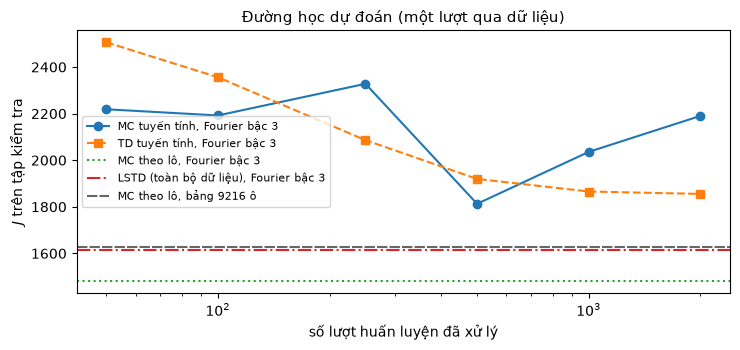

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for m, st in [("MC", dict(ls="-", marker="o")), ("TD", dict(ls="--", marker="s"))]:
    k, j = zip(*results_pred[(m, "Fourier bậc 3")][1])            # (số lượt đã xử lý, J) tại các mốc
    ax.plot(k, j, label=f"{m} tuyến tính, Fourier bậc 3", **st)
ax.axhline(results_pred[("MC theo lô", "Fourier bậc 3")][1][-1][1], ls=":", color="C2", label="MC theo lô, Fourier bậc 3")
ax.axhline(results_pred[("LSTD", "Fourier bậc 3")][1][-1][1], ls="-.", color="C3", label="LSTD (toàn bộ dữ liệu), Fourier bậc 3")
ax.axhline(J_tab, ls=(0, (5, 1)), color="0.4", label="MC theo lô, bảng 9216 ô")   # mốc dạng bảng của Bài 05
ax.set_xscale("log"); ax.set_xlabel("số lượt huấn luyện đã xử lý"); ax.set_ylabel("$J$ trên tập kiểm tra")
ax.set_title("Đường học dự đoán (một lượt qua dữ liệu)", fontsize=11); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Câu hỏi:** (a) Với cùng họ Fourier bậc 3 và cùng dữ liệu, giải thích vì sao MC theo lô và LSTD cho hai vector trọng số khác nhau. (b) Nếu tăng số lượt huấn luyện lên rất lớn, xác định điểm mà mỗi nghiệm hướng tới và nêu ý nghĩa của chặn $\frac1{1-\gamma}$ đối với khoảng cách giữa hai đích khi $\gamma=0{,}99$.

<details><summary>Lời giải</summary>

(a) MC theo lô cực tiểu tổng bình phương sai lệch tới lợi tức quan sát, tức tìm hình chiếu của lợi tức lên không gian con $\{\Phi w\}$ theo phân phối ghé của dữ liệu. LSTD giải $\hat Aw=\hat b$, tức điểm mà hình chiếu của ảnh Bellman $\Pi_DT_\pi(\Phi w)$ trùng $\Phi w$. Khi $v_\pi$ không nằm trong lớp biểu diễn, hai điều kiện này cho hai điểm khác nhau (ghi chú Bài 07, mục 10.3 và 11.1). Trên cùng các lượt kết thúc thật, output cho $1622$ (LSTD) so với $1481$ (MC theo lô) với họ Fourier bậc 3, nên chênh lệch không đến từ việc LSTD dùng thêm lượt cắt ngắn. Khi trạng thái quan sát không đủ thông tin Markov, quan hệ Bellman trên quan sát cũng không đúng hẳn, nên LSTD còn chịu thêm sai lệch đó.

(b) Dưới các giả thiết của mục 10.4, nghiệm MC tiến tới $\Pi_Dv_\pi$ và nghiệm TD tới điểm cố định Bellman chiếu $w_{\mathrm{TD}}$. Chặn của Sutton–Barto §9.4, phát biểu cho trường hợp liên tục, cho $\overline{\mathrm{VE}}(w_{\mathrm{TD}})\le100\,\min_w\overline{\mathrm{VE}}(w)$ khi $\gamma=0{,}99$: nếu lớp biểu diễn đã tốt thì sai số của TD cũng nhỏ, nhưng chặn không loại trừ việc TD kém hơn MC nhiều lần khi lớp biểu diễn còn sai số đáng kể.

</details>

## 9. Trực quan hóa dự đoán

**Dọc một lượt.** Đồ thị dưới lấy lượt kiểm tra kết thúc thật đầu tiên (không chọn theo kết quả) và vẽ lợi tức thực tế $G_t$ cùng các dự đoán $\hat v(S_t,w)$ của MC theo lô và LSTD với họ Fourier bậc 3, và của bảng $9216$ ô. Dự đoán dạng bảng là hàm bậc thang theo thời gian: nó chỉ đổi khi tàu sang ô khác. Dự đoán tuyến tính đổi liên tục theo quan sát. Một lượt chỉ là một mẫu; $J$ ở mục 8 là thước đo trên toàn tập kiểm tra.

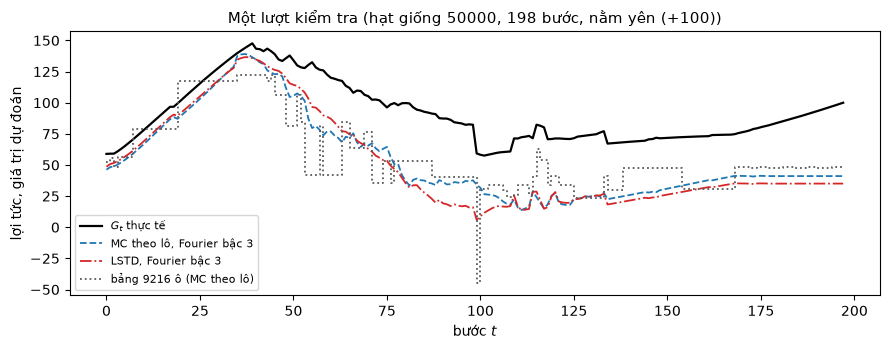

MC theo lô, Fourier bậc 3    sai số bình phương trung bình trên lượt này:   1583.6
LSTD, Fourier bậc 3          sai số bình phương trung bình trên lượt này:   1881.2
bảng 9216 ô (MC theo lô)     sai số bình phương trung bình trên lượt này:   1571.1


In [19]:
ep_v = next(e for e in test if e["terminated"])                # lượt kiểm tra kết thúc thật đầu tiên
Gv = returns(ep_v["rewards"], GAMMA); Ov = ep_v["obs"][:-1]; t = np.arange(len(Gv))
phi3, _ = make_fourier(3)
curves = {"MC theo lô, Fourier bậc 3": (phi3(Ov) @ results_pred[("MC theo lô", "Fourier bậc 3")][0], dict(ls="--", color="C0")),
          "LSTD, Fourier bậc 3": (phi3(Ov) @ results_pred[("LSTD", "Fourier bậc 3")][0], dict(ls="-.", color="C3")),
          "bảng 9216 ô (MC theo lô)": (V_tab[cell_of(Ov)], dict(ls=":", color="0.35", drawstyle="steps-post"))}
fig, ax = plt.subplots(figsize=(9, 3.6))                          # G_t và ba dự đoán dọc lượt
ax.plot(t, Gv, color="k", lw=1.6, label="$G_t$ thực tế")
for lab, (v, st) in curves.items():
    ax.plot(t, v, lw=1.3, label=lab, **st)
ax.set_xlabel("bước $t$"); ax.set_ylabel("lợi tức, giá trị dự đoán")
ax.set_title(f"Một lượt kiểm tra (hạt giống {ep_v['seed']}, {len(Gv)} bước, {outcome(ep_v)})", fontsize=11)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
for lab, (v, _) in curves.items():
    print(f"{lab:<28} sai số bình phương trung bình trên lượt này: {np.mean((Gv - v) ** 2):8.1f}")

**Trên mặt phẳng $(x,y)$.** Hình dưới vẽ $\hat v$ trên một lát cắt của không gian quan sát: $x\in[-1,1]$, $y\in[0;1{,}5]$, các biến còn lại cố định tại $v_x=0$, $v_y=-0{,}3$ (tàu đang hạ chậm), $\varphi=\omega=0$ và hai chân chưa chạm đất. Bên trái là LSTD với họ Fourier bậc 3, bên phải là bảng $9216$ ô; ô chưa được ghé của bảng giữ giá trị $0$ và được ghi dấu `–`. Cả hai hình dùng chung một thang màu và được ghi số tại một số điểm, nên đọc được mà không cần phân biệt màu. Ô mã in tỉ lệ điểm của lát cắt rơi vào ô đã được ghé. Ở các điểm thuộc ô chưa ghé, bảng không có thông tin, còn hàm tuyến tính vẫn cho một giá trị do tổng quát hóa từ các trạng thái khác; giá trị đó không có dữ liệu trực tiếp kiểm chứng. Ô mã in thêm khoảng giá trị của $\hat v$ trên lát cắt cạnh khoảng lợi tức $G_t$ quan sát được trong tập huấn luyện (in ở mục 5); giá trị nằm ngoài khoảng lợi tức là ngoại suy của hàm tuyến tính.

tỉ lệ điểm của lát cắt thuộc ô đã ghé: 0.22
LSTD trên lát cắt: [-81.0; 388.2]; khoảng G_t huấn luyện: [-230.4; 178.6]; tỉ lệ điểm ngoài khoảng: 0.16


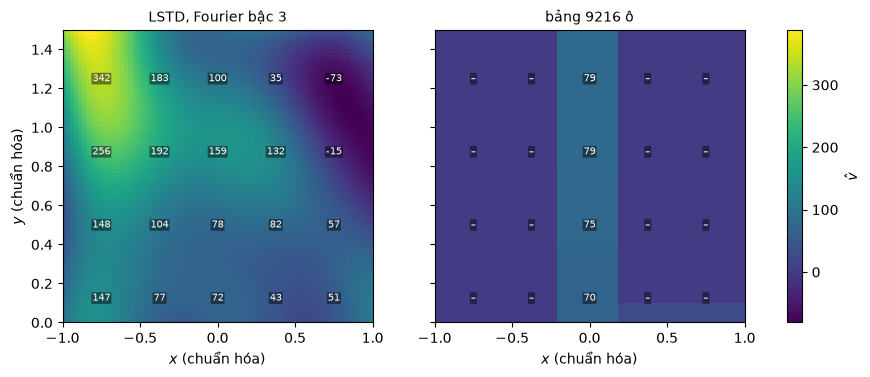

In [20]:
xs, ys = np.linspace(-1, 1, 81), np.linspace(0, 1.5, 61)
XX, YY = np.meshgrid(xs, ys)
grid = np.zeros((XX.size, 8)); grid[:, 0] = XX.ravel(); grid[:, 1] = YY.ravel()
grid[:, 3] = -0.3                                                # v_y = -0,3; các biến khác bằng 0
visited = (cnt[cell_of(grid)] > 0).reshape(XX.shape)            # điểm thuộc ô bảng đã được ghé
print(f"tỉ lệ điểm của lát cắt thuộc ô đã ghé: {visited.mean():.2f}")
maps = {"LSTD, Fourier bậc 3": (phi3(grid) @ results_pred[("LSTD", "Fourier bậc 3")][0]).reshape(XX.shape),
        "bảng 9216 ô": V_tab[cell_of(grid)].reshape(XX.shape)}
M_l = maps["LSTD, Fourier bậc 3"]
out = (M_l < G_train_all.min()) | (M_l > G_train_all.max())          # ngoài khoảng lợi tức của tập huấn luyện
print(f"LSTD trên lát cắt: [{M_l.min():.1f}; {M_l.max():.1f}]; khoảng G_t huấn luyện: "
      f"[{G_train_all.min():.1f}; {G_train_all.max():.1f}]; tỉ lệ điểm ngoài khoảng: {out.mean():.2f}")
vmin = min(m.min() for m in maps.values()); vmax = max(m.max() for m in maps.values())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (lab, M) in zip(axes, maps.items()):
    im = ax.imshow(M, origin="lower", extent=(-1, 1, 0, 1.5), aspect="auto", vmin=vmin, vmax=vmax, cmap="viridis")
    for i in range(5, len(ys), 15):                                 # ghi số tại một số điểm
        for j in (10, 25, 40, 55, 70):                       # x = -0,75; -0,375; 0; 0,375; 0,75
            txt = f"{M[i, j]:.0f}" if (lab.startswith("LSTD") or visited[i, j]) else "–"
            ax.text(xs[j], ys[i], txt, ha="center", va="center", fontsize=7, color="w",
                    bbox=dict(boxstyle="round,pad=0.1", fc="k", alpha=0.45, lw=0))
    ax.set_title(lab, fontsize=10); ax.set_xlabel("$x$ (chuẩn hóa)")
axes[0].set_ylabel("$y$ (chuẩn hóa)")
fig.colorbar(im, ax=axes, label=r"$\hat v$"); plt.show()

**Câu hỏi:** Trên lát cắt ở trên, giải thích vì sao bảng cho các khối giá trị hằng còn hàm tuyến tính cho mặt cong liên tục, và vì sao một cập nhật MC hoặc TD tại một trạng thái gần bãi đáp làm đổi dự đoán của hàm Fourier ở những điểm xa trên lát cắt, còn với bảng thì không.

<details><summary>Lời giải</summary>

Với bảng, $x(s)$ là vector one-hot của ô, nên $\hat v$ hằng trên mỗi ô và nhảy bậc ở ranh giới ô. Với cơ sở Fourier, $\hat v(s,w)=\sum_c w_c\cos(\pi c^\top z(s))$ là tổng các hàm cos trơn của $z$, nên liên tục theo quan sát (trừ chỗ các biến bị cắt ở biên). Cập nhật cộng vào $w$ một bội của $x(S_t)$. Với bảng, chỉ thành phần của ô chứa $S_t$ khác $0$, nên chỉ ô đó đổi. Với cơ sở Fourier, mọi thành phần $\cos(\pi c^\top z(S_t))$ nói chung khác $0$, nên mọi trọng số đổi, và dự đoán ở điểm $s'$ đổi một lượng $\alpha\,\delta\,x(S_t)^\top x(s')$, khác $0$ cả khi $s'$ ở xa $S_t$ (ghi chú Bài 07, mục 3.2).

</details>

# Phần B — Điều khiển với xấp xỉ hàm tuyến tính

## 10. Đặc trưng cho cặp trạng thái–hành động

**Vấn đề.** Phần A ước lượng $v_\pi$ của một chính sách cho trước. Muốn chọn hành động mà không có mô hình chuyển, cần giá trị hành động $\hat q(s,a,w)=x(s,a)^\top w$ (ghi chú Bài 07, mục 12.1). Vector đặc trưng vì vậy phải phụ thuộc cả trạng thái lẫn hành động.

**Trực giác.** Nếu chỉ dùng $\phi(s)$ chung cho mọi hành động, bốn hành động nhận cùng dự đoán và không có gì để so sánh. Cần một phần trọng số riêng cho từng hành động trên chính các đặc trưng trạng thái, để hành động tốt nhất có thể đổi theo trạng thái.

**Mã hóa bốn khối** (ghi chú Bài 07, mục 5.2; bài giảng gốc tr. 31). Với $\phi(s)\in\mathbb R^p$, $m=4$ hành động và mã one-hot $e_a\in\mathbb R^m$,

$$x(s,a)=\begin{bmatrix}\phi(s)\\ e_a\\ \phi(s)\otimes e_a\\ 1\end{bmatrix}\in\mathbb R^{d},\qquad d=p+m+mp+1 .$$

Tách $w$ thành bốn khối $w^{(1)}\in\mathbb R^p$, $c\in\mathbb R^m$, $u_1,\dots,u_m\in\mathbb R^p$ và $b$:

$$\hat q(s,a,w)=\phi(s)^\top\bigl(w^{(1)}+u_a\bigr)+c_a+b .$$

Phần B dùng họ Fourier bậc 3 của mục 4 ($p=156$), nên $d=156+4+624+1=785$. Gradient theo $w$ là $x(s,a)$, nên một cập nhật $w\leftarrow w+\alpha\,\delta\,x(S,A)$ cộng $\alpha\delta\,\phi(S)$ vào $w^{(1)}$ và vào $u_A$, cộng $\alpha\delta$ vào $c_A$ và vào $b$.

| Ký hiệu | Biến trong mã | Kích thước |
| --- | --- | --- |
| $\phi(s)$ | `phi3(obs)` | $(156,)$ |
| $w^{(1)}$, $(u_a)_a$, $c$, $b$ | `Q.w1`, `Q.U`, `Q.c`, `Q.b` của lớp `LinearQ` | $(156,)$, $(4,156)$, $(4,)$, số |
| $\hat q(s,\cdot,w)$ | `Q.q(f)` với `f = phi3(obs)` | $(4,)$ |
| $x(s,a)$ dạng tường minh | `x_sa(f, a)` (chỉ dùng để kiểm tra) | $(785,)$ |

Lớp `LinearQ` lưu bốn khối riêng thay cho vector $785$ chiều: $\hat q(s,\cdot,w)$ cho cả bốn hành động chỉ cần một phép nhân ma trận $(4,156)\times(156,)$. Ô mã sau kiểm bằng `assert` rằng cách lưu này cho đúng $x(s,a)^\top w$.

**Không đủ hạng cột.** Khối $\phi(s)$ bằng tổng theo $a$ của các tọa độ tương ứng trong khối $\phi(s)\otimes e_a$, và $1$ bằng tổng các thành phần của $e_a$ (ghi chú, mục 5.2). Vì vậy cộng một vector $v$ vào $w^{(1)}$ rồi trừ $v$ khỏi mọi $u_a$ không đổi dự đoán nào: nhiều $w$ cho cùng hàm $\hat q$. Ô mã kiểm tính chất này trên một quan sát.

In [21]:
# Hạt giống của phần B, cùng giá trị với thực hành Bài 06 để đánh giá cuối dùng cùng tập lượt
TRAIN_SEED = 20_000     # hạt giống môi trường khi huấn luyện (mục 12); trùng DATA_TRAIN_SEED theo quy ước Bài 05/06
AGENT_SEED = 1          # hạt giống của bộ sinh số ngẫu nhiên của tác tử khi huấn luyện
VALID_SEED = 40_000     # hạt giống các lượt đánh giá định kỳ trong lúc huấn luyện
TEST_SEED = 30_000      # hạt giống các lượt đánh giá cuối cùng (mục 12.2)
M_ACT = 4               # số hành động


class LinearQ:
    # q_hat(s, a, w) = phi(s)^T (w1 + U[a]) + c[a] + b, lưu theo bốn khối của x(s, a)
    def __init__(self, p):
        self.w1 = np.zeros(p); self.U = np.zeros((M_ACT, p)); self.c = np.zeros(M_ACT); self.b = 0.0

    def q(self, f):                                    # f = phi(s), cỡ (p,) -> q_hat(s, ., w), cỡ (4,)
        return f @ self.w1 + self.U @ f + self.c + self.b

    def update(self, f, a, step):                      # w <- w + step * x(s, a), step = alpha * delta
        self.w1 += step * f; self.U[a] += step * f; self.c[a] += step; self.b += step

    def vector(self):                                  # w theo thứ tự [w1; c; U ghép theo phi ⊗ e_a; b], cỡ (d,)
        return np.concatenate([self.w1, self.c, self.U.T.ravel(), [self.b]])

    def norm(self):
        return float(np.linalg.norm(self.vector()))


def x_sa(f, a):
    # x(s, a) = [phi; e_a; phi ⊗ e_a; 1] dạng tường minh, cỡ (p + 4 + 4p + 1,)
    e = np.zeros(M_ACT); e[a] = 1.0
    return np.concatenate([f, e, np.kron(f, e), [1.0]])


phi3, p3 = make_fourier(3)
o = episodes_ref["heuristic"]["obs"][0]                # quan sát đầu của lượt minh họa ở mục 3.1
f = phi3(o)
Qt = LinearQ(p3)
rng_chk = np.random.default_rng(0)                     # trọng số ngẫu nhiên chỉ để kiểm tra phép tính
Qt.w1, Qt.U, Qt.c, Qt.b = rng_chk.normal(size=p3), rng_chk.normal(size=(4, p3)), rng_chk.normal(size=4), 0.3
w_vec = Qt.vector()
for a in range(M_ACT):
    assert np.isclose(x_sa(f, a) @ w_vec, Qt.q(f)[a])  # lưu theo khối cho đúng x(s,a)^T w
print("d =", len(w_vec), "| q_hat(s, ., w) =", Qt.q(f).round(3))

shift = rng_chk.normal(size=p3)                        # cộng vào w1, trừ khỏi mọi U[a]
q_before = Qt.q(f).copy()
Qt.w1 = Qt.w1 + shift; Qt.U = Qt.U - shift
assert np.allclose(Qt.q(f), q_before)
print("sau khi dời trọng số giữa hai khối, q_hat không đổi:", Qt.q(f).round(3))

d = 785 | q_hat(s, ., w) = [-6.563 -9.137 -4.167 -3.346]
sau khi dời trọng số giữa hai khối, q_hat không đổi: [-6.563 -9.137 -4.167 -3.346]


**Chính sách $\varepsilon$-tham lam theo $\hat q$.** Như Bài 06 (ghi chú Bài 06, mục 2.5), với $\mathcal G(s)=\arg\max_a\hat q(s,a,w)$,

$$\pi_\varepsilon(a\mid s)=\frac{\varepsilon}{m}+(1-\varepsilon)\frac{\mathbf 1\{a\in\mathcal G(s)\}}{|\mathcal G(s)|}.$$

Chỉ khác Bài 06 ở chỗ hàng $Q(s,\cdot)$ của bảng được thay bằng vector $\hat q(s,\cdot,w)$ tính từ đặc trưng. Hàm `epsilon_greedy_action` dưới giống hệt Bài 06; `linear_epsilon` là lịch giảm tuyến tính của Bài 06.

In [22]:
def epsilon_greedy_action(q_row, eps, rng):
    # Lấy mẫu A ~ pi_eps(. | s): với xác suất eps chọn đều; còn lại chọn đều trong tập cực đại
    if rng.random() < eps:
        return int(rng.integers(len(q_row)))
    greedy_set = np.flatnonzero(q_row == q_row.max())
    return int(greedy_set[0]) if len(greedy_set) == 1 else int(greedy_set[rng.integers(len(greedy_set))])


def linear_epsilon(k, eps_start=1.0, eps_end=0.05, k_decay=1500):
    # eps_k giảm tuyến tính từ eps_start tới eps_end trong k_decay lượt đầu, sau đó giữ eps_end
    return max(eps_end, eps_start - (eps_start - eps_end) * k / k_decay)


rng_chk = np.random.default_rng(0)
q_row = np.array([1.0, 3.0, 3.0, 0.0])                 # hai hành động đồng hạng
freq = np.bincount([epsilon_greedy_action(q_row, 0.2, rng_chk) for _ in range(100_000)], minlength=4) / 100_000
print("tần suất trên 100 000 lần lấy mẫu:", freq.round(3), "| công thức: [0.05 0.45 0.45 0.05]")
assert np.allclose(freq, [0.05, 0.45, 0.45, 0.05], atol=0.006)
print("eps_k tại k = 0, 750, 1500, 2999:", [round(linear_epsilon(k), 3) for k in (0, 750, 1500, 2999)])

tần suất trên 100 000 lần lấy mẫu: [0.049 0.451 0.45  0.05 ] | công thức: [0.05 0.45 0.45 0.05]
eps_k tại k = 0, 750, 1500, 2999: [1.0, 0.525, 0.05, 0.05]


## 11. Sarsa và Q-learning tuyến tính

**Vấn đề.** Bài 06 cập nhật một ô của bảng; ở đây chỉ có vector $w$ dùng chung, nên mỗi cập nhật đổi $\hat q$ ở mọi trạng thái có đặc trưng khác $0$.

**Trực giác.** Mục tiêu cập nhật giữ nguyên dạng của Bài 06, chỉ thay giá trị trong bảng bằng $\hat q$; phép "dịch ô về phía mục tiêu" được thay bằng một bước bán gradient theo $w$ (ghi chú Bài 07, mục 12.3 và 13.1):

$$y_t=\begin{cases}R_{t+1}, & S_{t+1}\ \text{kết thúc},\\ R_{t+1}+\gamma\,\hat q(S_{t+1},A_{t+1},w_t) & \text{(Sarsa)},\\ R_{t+1}+\gamma\max_{a'}\hat q(S_{t+1},a',w_t) & \text{(Q-learning)},\end{cases}\qquad w_{t+1}=w_t+\alpha\,\bigl[y_t-\hat q(S_t,A_t,w_t)\bigr]\,x(S_t,A_t).$$

Mục tiêu $y_t$ chứa $w_t$ nhưng được giữ cố định khi lấy đạo hàm, nên đây là bán gradient như TD(0) ở mục 7.

**Một cập nhật đổi dự đoán tại chính cặp đó bao nhiêu.** Vì $\hat q$ tuyến tính,

$$\hat q(S_t,A_t,w_{t+1})-\hat q(S_t,A_t,w_t)=\alpha\,\delta_t\,\lVert x(S_t,A_t)\rVert^2,\qquad \delta_t=y_t-\hat q(S_t,A_t,w_t).$$

Với bốn khối, $\lVert x(s,a)\rVert^2=\lVert\phi(s)\rVert^2+1+\lVert\phi(s)\rVert^2+1=2\lVert\phi(s)\rVert^2+2$. Chọn $\alpha=c/\mathbb E[\lVert x(s,a)\rVert^2]$ (Sutton–Barto, ấn bản 2, §9.6) nghĩa là mỗi cập nhật dịch dự đoán tại cặp vừa gặp khoảng một phần $c$ của sai lệch, như bước học $c$ của bảng. Phần B dùng $c=0{,}1$; giá trị này được chọn bằng thử nghiệm ở mục 12.3.

**Tính tay.** Lấy $p=2$ để mọi số tính được bằng tay: $\phi(S)=(1;\,0{,}5)$, $\phi(S')=(0{,}5;\,1)$, $w^{(1)}=(1;\,0)$, $u_2=(0;\,1)$, các $u_a$ khác bằng $0$, $c=(0;\,0{,}5;\,0;\,0)$, $b=0$. Khi đó
$$\hat q(S',\cdot,w)=\phi(S')^\top w^{(1)}+\bigl(\phi(S')^\top u_a\bigr)_a+c=(0{,}5;\,1;\,1{,}5;\,0{,}5),\qquad \hat q(S,0,w)=1.$$
Với chuyển $(S,A=0,R=-1,S')$, $\gamma=0{,}9$, $\alpha=0{,}1$ và hành động kế tiếp $A'=1$ do thăm dò (không phải hành động cực đại $2$):

- Sarsa: $y=-1+0{,}9\cdot\hat q(S',1,w)=-1+0{,}9\cdot1=-0{,}1$, $\delta=-1{,}1$;
- Q-learning: $y=-1+0{,}9\cdot\max_a\hat q(S',a,w)=-1+0{,}9\cdot1{,}5=0{,}35$, $\delta=-0{,}65$.

Với $\lVert x(S,0)\rVert^2=2\lVert\phi(S)\rVert^2+2=2\cdot1{,}25+2=4{,}5$, dự đoán mới tại $(S,0)$ là $1+0{,}1\cdot(-1{,}1)\cdot4{,}5=0{,}505$ (Sarsa) và $1+0{,}1\cdot(-0{,}65)\cdot4{,}5=0{,}7075$ (Q-learning). Cập nhật chỉ đổi $w^{(1)}$, $u_0$, $c_0$ và $b$; $u_1,u_2,u_3$ giữ nguyên. Ô mã kiểm các số này bằng lớp `LinearQ`.

In [23]:
Qh = LinearQ(2)
Qh.w1 = np.array([1.0, 0.0]); Qh.U[2] = [0.0, 1.0]; Qh.c = np.array([0.0, 0.5, 0.0, 0.0])
f_s, f_s2 = np.array([1.0, 0.5]), np.array([0.5, 1.0])               # phi(S), phi(S')
q_next = Qh.q(f_s2)                                                    # q_hat(S', ., w), cỡ (4,)
assert np.allclose(q_next, [0.5, 1.0, 1.5, 0.5]) and np.isclose(Qh.q(f_s)[0], 1.0)
y_sarsa = -1 + 0.9 * q_next[1]                                         # A' = 1
y_q = -1 + 0.9 * q_next.max()
for name, y, q_expect in [("Sarsa", y_sarsa, 0.505), ("Q-learning", y_q, 0.7075)]:
    Qc = LinearQ(2); Qc.w1, Qc.U, Qc.c = Qh.w1.copy(), Qh.U.copy(), Qh.c.copy()
    delta = y - Qc.q(f_s)[0]
    Qc.update(f_s, 0, 0.1 * delta)                                     # w <- w + alpha * delta * x(S, 0)
    assert np.isclose(Qc.q(f_s)[0], q_expect) and np.allclose(Qc.U[1:], Qh.U[1:])
    print(f"{name:<10}: y = {y:.4f}, delta = {delta:.4f}, q_hat(S, 0) mới = {Qc.q(f_s)[0]:.4f}")

Sarsa     : y = -0.1000, delta = -1.1000, q_hat(S, 0) mới = 0.5050
Q-learning: y = 0.3500, delta = -0.6500, q_hat(S, 0) mới = 0.7075


**Thuật toán Sarsa tuyến tính** (ghi chú Bài 07, mục 12.5), ngân sách $K$ lượt:

1. $w\leftarrow0$. Đầu mỗi lượt: lấy $S$, chọn $A$ theo $\pi_\varepsilon$ của $\hat q(S,\cdot,w)$.
2. Thực hiện $A$, nhận $R$, $S'$. Nếu $S'$ kết thúc: $y\leftarrow R$. Ngược lại chọn $A'$ theo $\pi_\varepsilon$ của $\hat q(S',\cdot,w)$ (dùng $w$ trước cập nhật), $y\leftarrow R+\gamma\hat q(S',A',w)$.
3. $w\leftarrow w+\alpha\,[y-\hat q(S,A,w)]\,x(S,A)$.
4. Nếu lượt chưa dừng: $S\leftarrow S'$, $A\leftarrow A'$, về bước 2.

**Q-learning tuyến tính** khác ở bước 2: $y\leftarrow R+\gamma\max_{a'}\hat q(S',a',w)$, và hành động kế tiếp được chọn sau cập nhật theo $\pi_\varepsilon$ của $w$ mới. Khi lượt bị cắt ngắn ở $1000$ bước, $S'$ chưa kết thúc nên mục tiêu vẫn bootstrap, như Bài 06.

| Ký hiệu | Biến trong mã |
| --- | --- |
| $\phi(S)$, $\phi(S')$ | `f`, `f2` |
| $\hat q(S,\cdot,w)$, $\hat q(S',\cdot,w)$ (trước cập nhật) | `qv`, `q2` |
| $y$, $\delta$, $\alpha$ | `y`, `y - qv[a]`, `alpha` |
| $\lVert w\rVert$ sau mỗi lượt | `log["wnorm"]` |

Hàm `train_linear` dưới cài cả hai thuật toán (đối số `algo`), ghi tổng thưởng, độ dài, cách dừng, $\varepsilon_k$ và $\lVert w\rVert$ của từng lượt, và đánh giá chính sách tham lam định kỳ nếu được yêu cầu. Đối số `trace` lưu các cập nhật đầu để kiểm tra.

In [24]:
def train_linear(algo, phi, p, n_episodes, gamma, eps_fn, alpha, env_seed, agent_seed,
                 eval_every=0, eval_fn=None, trace=0):
    env_t = make_env()
    Q = LinearQ(p)                                         # bước 1: w = 0
    rng = np.random.default_rng(agent_seed)
    log = {"total": [], "length": [], "outcome": [], "eps": [], "wnorm": []}
    evals, traced = [], []
    for k in range(n_episodes):
        eps = eps_fn(k)
        obs, _ = env_t.reset(seed=env_seed + k)
        f = phi(obs); qv = Q.q(f)
        a = epsilon_greedy_action(qv, eps, rng)
        total, steps = 0.0, 0
        while True:
            obs, r, terminated, truncated, _ = env_t.step(a)   # bước 2: thực hiện A, nhận R, S'
            total += r; steps += 1
            f2 = phi(obs); q2 = Q.q(f2)                    # q_hat(S', ., w) trước cập nhật
            if terminated:
                y, a2 = r, None
            elif algo == "sarsa":
                a2 = epsilon_greedy_action(q2, eps, rng)   # A' chọn bằng w trước cập nhật
                y = r + gamma * q2[a2]
            else:
                a2 = None
                y = r + gamma * q2.max()                   # Q-learning: cực đại trên w trước cập nhật
            step = alpha * (y - qv[a])                     # alpha * delta
            Q.update(f, a, step)                           # bước 3: w <- w + alpha * delta * x(S, A)
            if len(traced) < trace:
                traced.append(dict(r=r, terminal=terminated, a=a, a2=a2, q_old=qv[a], q_next=q2, y=y,
                                   step=step, sq=2 * f @ f + 2, q_new=Q.q(f)[a]))
            if terminated or truncated:
                break
            f = f2; qv = Q.q(f2)                           # q_hat(S', ., w) với w mới
            a = a2 if algo == "sarsa" else epsilon_greedy_action(qv, eps, rng)   # bước 4
        log["total"].append(total); log["length"].append(steps); log["eps"].append(eps)
        log["outcome"].append(("nằm yên (+100)" if r == 100 else "rơi hoặc ra ngoài (-100)") if terminated
                              else "cắt ngắn 1000 bước")
        log["wnorm"].append(Q.norm())
        if eval_every and (k + 1) % eval_every == 0:
            evals.append((k + 1,) + eval_fn(Q))
    return {"Q": Q, "log": {key: np.array(v) for key, v in log.items()}, "evals": evals, "trace": traced}


def mean_sqnorm_x(phi, data):
    # E||x(s, a)||^2 = 2 E||phi(s)||^2 + 2 trên các quan sát của một tập lượt (data nhỏ nên ghép một lần)
    O = np.concatenate([e["obs"][:-1] for e in data])
    return 2 * float(np.mean(np.sum(phi(O) ** 2, axis=1))) + 2


C_STEP = 0.1
# 200 lượt đầu của tập huấn luyện phần A: cùng cách tính alpha với thử nghiệm chọn cấu hình ở mục 12.3
ALPHA = C_STEP / mean_sqnorm_x(phi3, train[:200])
print(f"E||x(s,a)||^2 = {C_STEP / ALPHA:.1f}  ->  alpha = {ALPHA:.2e}")

E||x(s,a)||^2 = 161.5  ->  alpha = 6.19e-04


**Kiểm tra trên dữ liệu thật.** Ô mã sau chạy mỗi thuật toán $3$ lượt với $\varepsilon=1$, lưu tối đa $300$ cập nhật đầu (số cập nhật thực tế của $3$ lượt in ở output) và tính lại từng cập nhật bằng công thức: mục tiêu $y$ từ $R$ và hàng $\hat q(S',\cdot,w)$ trước cập nhật, rồi dự đoán mới tại $(S,A)$ theo đẳng thức $\hat q_{\text{mới}}=\hat q_{\text{cũ}}+\alpha\delta\lVert x(S,A)\rVert^2$. Một cập nhật đầu tiên được in đầy đủ.

In [25]:
for algo in ["sarsa", "q"]:
    chk = train_linear(algo, phi3, p3, 3, GAMMA, eps_fn=lambda k: 1.0, alpha=ALPHA,
                       env_seed=TRAIN_SEED, agent_seed=AGENT_SEED, trace=300)
    for u in chk["trace"]:
        if u["terminal"]:
            y_hand = u["r"]
        elif algo == "sarsa":
            y_hand = u["r"] + GAMMA * u["q_next"][u["a2"]]
        else:
            y_hand = u["r"] + GAMMA * u["q_next"].max()
        assert np.isclose(y_hand, u["y"])
        assert np.isclose(u["q_old"] + u["step"] * u["sq"], u["q_new"])   # q_moi = q_cu + alpha*delta*||x||^2
    # In cập nhật đầu tiên mà A' (Sarsa) không đạt cực đại của q_hat(S', ., w), hoặc cập nhật cùng chỉ số (Q-learning)
    if algo == "sarsa":
        j = next(i for i, u in enumerate(chk["trace"])
                 if u["a2"] is not None and u["q_next"][u["a2"]] < u["q_next"].max() - 1e-12)
    u = chk["trace"][j]
    print(f"{algo:<6}: {len(chk['trace'])} cập nhật khớp. Cập nhật thứ {j + 1}: R = {u['r']:.3f}, "
          f"q_hat(S', ., w) = {np.round(u['q_next'], 3)}, A' = {u['a2']}, y = {u['y']:.4f}, "
          f"q_hat(S, A): {u['q_old']:.4f} -> {u['q_new']:.4f}")

sarsa : 283 cập nhật khớp. Cập nhật thứ 5: R = 0.546, q_hat(S', ., w) = [-0.241 -0.198 -0.196 -0.343], A' = 1, y = 0.3500, q_hat(S, A): -0.1996 -> -0.1455
q     : 283 cập nhật khớp. Cập nhật thứ 5: R = 0.546, q_hat(S', ., w) = [-0.241 -0.198 -0.196 -0.343], A' = None, y = 0.3528, q_hat(S, A): -0.1996 -> -0.1453


## 12. Huấn luyện và đánh giá

Mỗi thuật toán học $K=3000$ lượt với hạt giống môi trường `TRAIN_SEED + k` và cùng lịch $\varepsilon_k$ giảm tuyến tính từ $1$ xuống $0{,}05$ trong $1500$ lượt đầu, như thiết lập gốc của Bài 06; $w_0=0$, $\gamma=0{,}99$, $\alpha=0{,}1/\mathbb E\lVert x(s,a)\rVert^2$. Cứ $250$ lượt, chính sách tham lam $\pi_w(s)\in\arg\max_a\hat q(s,a,w)$ được đánh giá trên $10$ lượt `VALID_SEED` (không thăm dò, không cập nhật). Số lượt kiểm định nhỏ để mỗi lần đánh giá định kỳ chỉ mất vài giây; hệ quả là mỗi điểm có sai số chuẩn lớn, nên đường đánh giá định kỳ chỉ cho xu hướng. Mỗi thuật toán chạy khoảng hai đến ba phút trên CPU khi soạn; thời gian thực được in ở output.

In [26]:
def greedy_linear(Q, phi):
    # pi_w(s) in argmax_a q_hat(s, a, w), đồng hạng chọn đều; không thăm dò, không cập nhật
    def policy(obs, rng):
        return epsilon_greedy_action(Q.q(phi(obs)), 0.0, rng)
    return policy


N_TRAIN, EVAL_EVERY, N_VALID = 3000, 250, 10
eval_env = make_env()


def valid_eval(Q):
    # trả (trung bình, SE, số lượt cắt ngắn, y cuối lớn nhất, tỉ lệ bước có y hoặc v_y vượt biên chuẩn hóa)
    res = evaluate(eval_env, greedy_linear(Q, phi3), N_VALID, VALID_SEED, GAMMA)
    n_cut = sum(not e["terminated"] for e in res["episodes"])
    y_end = max(float(e["obs"][-1, 1]) for e in res["episodes"])
    O = np.concatenate([e["obs"][:-1] for e in res["episodes"]])
    clipped = np.mean((O[:, 1] > HI[1]) | (O[:, 3] > HI[3]))          # y > 1,6 hoặc v_y > 0,6: đặc trưng bị cắt
    return res["total"].mean(), res["total"].std(ddof=1) / np.sqrt(N_VALID), n_cut, y_end, clipped


trained = {}
for name, algo in [("Sarsa tuyến tính", "sarsa"), ("Q-learning tuyến tính", "q")]:
    t0 = time.time()
    trained[name] = train_linear(algo, phi3, p3, N_TRAIN, GAMMA, eps_fn=linear_epsilon, alpha=ALPHA,
                                 env_seed=TRAIN_SEED, agent_seed=AGENT_SEED,
                                 eval_every=EVAL_EVERY, eval_fn=valid_eval)
    out = trained[name]
    print(f"{name:<21}: {N_TRAIN} lượt, {time.time() - t0:.0f} giây; ||w|| cuối = {out['log']['wnorm'][-1]:.1f}; "
          f"đánh giá tham lam cuối trên tập kiểm định: {out['evals'][-1][1]:.1f} ± {out['evals'][-1][2]:.1f}")

Sarsa tuyến tính     : 3000 lượt, 172 giây; ||w|| cuối = 46.5; đánh giá tham lam cuối trên tập kiểm định: 233.6 ± 13.0


Q-learning tuyến tính: 3000 lượt, 152 giây; ||w|| cuối = 52.2; đánh giá tham lam cuối trên tập kiểm định: 173.3 ± 36.7


### 12.1. Đường học

Hình trái vẽ tổng thưởng của các lượt huấn luyện (chính sách hành vi có thăm dò), trung bình trượt $100$ lượt, cùng $\varepsilon_k$ trên trục phụ. Hình phải vẽ đánh giá định kỳ của chính sách tham lam kèm khoảng $\pm1{,}96\,\mathrm{SE}$ và hai mốc của phần 3. Mỗi điểm của hình phải chỉ dùng $10$ lượt nên khoảng tin cậy rộng. Trục tung bị cắt ở $-500$; điểm thấp hơn được vẽ ở mép dưới kèm giá trị thật. Hai đường ngang là trung bình của hai mốc trên $100$ lượt `EVAL_SEED` ở phần 3 (heuristic $255{,}4$); đánh giá cuối ở mục 12.2 dùng $100$ lượt `TEST_SEED` khác, trên đó heuristic đạt $236{,}9$. So sánh chính thức chỉ dùng `TEST_SEED`.

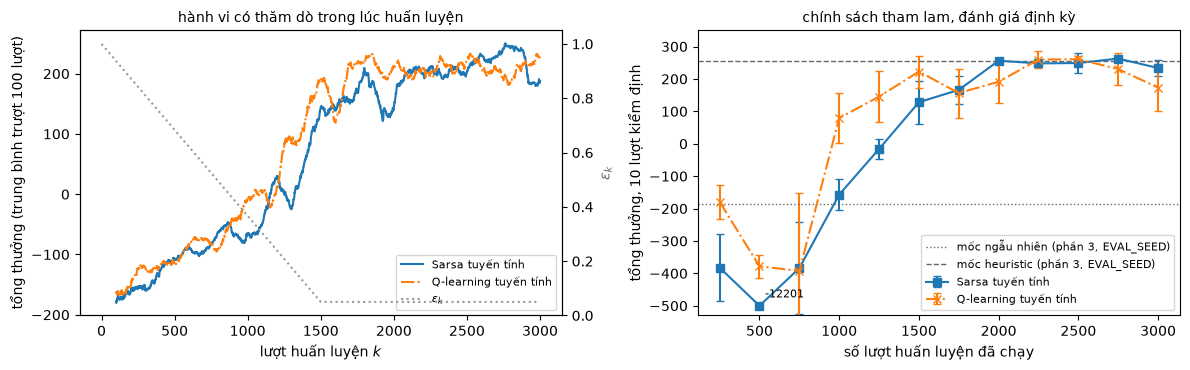

Sarsa tuyến tính      500 lượt huấn luyện cuối: tổng thưởng  222.9 | nằm yên (+100):  82%  rơi hoặc ra ngoài (-100):   8%  cắt ngắn 1000 bước:  10%
                      đánh giá định kỳ: thấp nhất -12200.7 (lượt 500; 10/10 lượt cắt ngắn, y cuối lớn nhất 167.6, bước có y > 1,6 hoặc v_y > 0,6: 94%), cao nhất  262.9 (lượt 2750)
Q-learning tuyến tính 500 lượt huấn luyện cuối: tổng thưởng  209.0 | nằm yên (+100):  78%  rơi hoặc ra ngoài (-100):  11%  cắt ngắn 1000 bước:  11%
                      đánh giá định kỳ: thấp nhất  -392.6 (lượt 750; 0/10 lượt cắt ngắn, y cuối lớn nhất 9.9, bước có y > 1,6 hoặc v_y > 0,6: 49%), cao nhất  260.8 (lượt 2500)


In [27]:
def moving_average(x, w=100):
    c = np.cumsum(np.insert(np.asarray(x, dtype=float), 0, 0.0))
    return (c[w:] - c[:-w]) / w


Y_LO = -500                                                   # cận dưới trục tung của hình phải
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for (name, out), ls, mk in zip(trained.items(), ["-", "-."], ["s", "x"]):
    axes[0].plot(np.arange(100, N_TRAIN + 1), moving_average(out["log"]["total"]), ls=ls, label=name)   # hình trái
    # hình phải: (lượt, trung bình, SE, số lượt cắt ngắn, y cuối lớn nhất, tỉ lệ bước vượt biên) của mỗi lần kiểm định
    ev = np.array(out["evals"])
    y_plot = np.maximum(ev[:, 1], Y_LO)                       # điểm thấp hơn Y_LO vẽ ở mép dưới
    axes[1].errorbar(ev[:, 0], y_plot, yerr=np.where(ev[:, 1] < Y_LO, 0, 1.96 * ev[:, 2]), ls=ls, marker=mk,
                     capsize=3, label=name)
    for k_, v_ in zip(ev[:, 0], ev[:, 1]):
        if v_ < Y_LO:                                         # ghi giá trị thật của điểm bị cắt
            axes[1].annotate(f"{v_:.0f}", (k_, Y_LO), textcoords="offset points", xytext=(4, 6), fontsize=8)
axes[1].set_ylim(Y_LO - 30, 350)
ax_eps = axes[0].twinx()                                      # trục phụ cho eps_k
ax_eps.plot(np.arange(N_TRAIN), [linear_epsilon(k) for k in range(N_TRAIN)], color="0.6", ls=":", label=r"$\varepsilon_k$")
ax_eps.set_ylabel(r"$\varepsilon_k$", color="0.4"); ax_eps.set_ylim(0, 1.05)
axes[0].set_xlabel("lượt huấn luyện $k$"); axes[0].set_ylabel("tổng thưởng (trung bình trượt 100 lượt)")
axes[0].set_title("hành vi có thăm dò trong lúc huấn luyện", fontsize=10)
h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = ax_eps.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, fontsize=8, loc="lower right")
for name, ls in [("ngẫu nhiên", ":"), ("heuristic", "--")]:
    axes[1].axhline(results_ref[name]["total"].mean(), color="0.4", ls=ls, lw=1, label=f"mốc {name} (phần 3, EVAL_SEED)")
axes[1].set_xlabel("số lượt huấn luyện đã chạy"); axes[1].set_ylabel(f"tổng thưởng, {N_VALID} lượt kiểm định")
axes[1].set_title("chính sách tham lam, đánh giá định kỳ", fontsize=10)
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()
for name, out in trained.items():                             # tóm tắt 500 lượt cuối và điểm kiểm định thấp nhất
    lg, last = out["log"], slice(N_TRAIN - 500, N_TRAIN)
    frac = "  ".join(f"{k}: {np.mean(lg['outcome'][last] == k):4.0%}" for k in OUTCOMES)
    ev = np.array(out["evals"])
    print(f"{name:<21} 500 lượt huấn luyện cuối: tổng thưởng {lg['total'][last].mean():6.1f} | {frac}")
    lo = ev[:, 1].argmin()
    print(f"{'':<21} đánh giá định kỳ: thấp nhất {ev[lo, 1]:7.1f} (lượt {int(ev[lo, 0])}; {int(ev[lo, 3])}/{N_VALID} lượt "
          f"cắt ngắn, y cuối lớn nhất {ev[lo, 4]:.1f}, bước có y > 1,6 hoặc v_y > 0,6: {ev[lo, 5]:.0%}), cao nhất {ev[:, 1].max():6.1f} (lượt {int(ev[ev[:, 1].argmax(), 0])})")

**Đọc đường học.** Ở các lượt đầu, $\varepsilon_k$ gần $1$ nên hành vi gần như ngẫu nhiên; tổng thưởng huấn luyện tăng dần khi $\varepsilon_k$ giảm. Đánh giá định kỳ dao động mạnh. Ở điểm thấp nhất của Sarsa (lượt $500$), output cho $10/10$ lượt bị cắt ngắn, độ cao cuối tới $167{,}6$ và tỉ lệ bước có $y>1{,}6$ hoặc $v_y>0{,}6$ là $94\%$: chính sách tham lam lúc đó đưa tàu bay lên tới khi hết $1000$ bước, và phần thưởng định hình phạt theo khoảng cách nên tổng thưởng rất âm. Điều này phù hợp với nhập nhằng do cắt biên ở mục 4: hàm `unit` cắt $y$ ở $1{,}6$ và $v_y$ ở $0{,}6$, nên khi tàu cao hơn hoặc bay lên nhanh hơn, các đặc trưng theo $y$ và $v_y$ không đổi, và $\hat q$ không phân biệt được tàu đang ở độ cao nào. Thực hành Bài 06 (mục 11.4) gặp hiện tượng tương tự với ô gộp $y\ge1{,}2$. Nhiệm vụ 10 ở phần 16 kiểm giả thuyết này. Mỗi điểm chỉ dùng $10$ lượt nên đường này cho biết xu hướng; mục 12.2 đánh giá $w$ ở lượt $3000$, một thời điểm dừng đặt trước, trên $100$ lượt `TEST_SEED`.

### 12.2. Đánh giá cuối

Bốn chính sách được đánh giá trên cùng $100$ lượt `TEST_SEED`: hai mốc của phần 3 và hai chính sách tham lam theo $\hat q$ sau $3000$ lượt. `TEST_SEED` không được dùng khi huấn luyện hay khi chọn cấu hình. Tập lượt này trùng tập đánh giá cuối của thực hành Bài 06; ô mã so tổng thưởng của hai mốc với số Bài 06 đã in, rồi đặt kết quả dạng bảng của Bài 06 (thiết lập gốc và bản tinh chỉnh) cạnh kết quả tuyến tính. Hai mốc chỉ trùng khi cùng phiên bản gymnasium, Box2D và numpy với lúc soạn (in ở phần 1); với phiên bản khác, ô mã in cả hai bộ số và các số Bài 06 chỉ còn giá trị tham khảo. Hai mốc ở đây khác số in ở phần 3 (heuristic $255{,}4$ trên `EVAL_SEED`) vì là hai tập $100$ lượt khác nhau; mọi so sánh chính thức của phần B dùng `TEST_SEED`.

In [28]:
N_TEST = 100
final_policies = {"ngẫu nhiên": random_policy, "heuristic": baselines["heuristic"],
                  "Sarsa tuyến tính": greedy_linear(trained["Sarsa tuyến tính"]["Q"], phi3),
                  "Q-learning tuyến tính": greedy_linear(trained["Q-learning tuyến tính"]["Q"], phi3)}
t0 = time.time()
final = {name: evaluate(eval_env, p, N_TEST, TEST_SEED, GAMMA) for name, p in final_policies.items()}
print(f"{N_TEST} lượt mỗi chính sách, cùng tập hạt giống TEST_SEED; trung bình ± SE ({time.time() - t0:.0f} giây)")
for name, res in final.items():
    summarize(name, res)
print()
for a_, b_ in [("Sarsa tuyến tính", "ngẫu nhiên"), ("Q-learning tuyến tính", "ngẫu nhiên"),
               ("heuristic", "Sarsa tuyến tính"), ("heuristic", "Q-learning tuyến tính"),
               ("Sarsa tuyến tính", "Q-learning tuyến tính")]:
    m, h = paired_difference(final[a_], final[b_])
    print(f"{a_} - {b_}: {m:7.1f} ± {h:5.1f} (khoảng 95%, ghép cặp)")

# Kết quả dạng bảng in ở mục 8.2 và 11.3 của notebook thực hành Bài 06, cùng 100 lượt TEST_SEED
LEC06_TEST = {"ngẫu nhiên": -194.8, "heuristic": 236.9,
              "Bài 06, Sarsa bảng 2187 ô (gốc)": 26.2, "Bài 06, Q-learning bảng 2187 ô (gốc)": -6.6,
              "Bài 06, Sarsa bảng tinh chỉnh": 202.8, "Bài 06, Q-learning bảng tinh chỉnh": 235.5}
# Cùng quy ước hạt giống và cùng phiên bản gói thì hai mốc trùng số Bài 06. Với phiên bản gymnasium,
# Box2D hoặc numpy khác (vd trên Colab), mô phỏng có thể lệch nhẹ nên chỉ so sánh và báo, không dừng.
same = all(abs(final[name]["total"].mean() - LEC06_TEST[name]) < 0.06 for name in ["ngẫu nhiên", "heuristic"])
if same:
    print("\nHai mốc trùng số in ở Bài 06, nên hai notebook dùng cùng 100 lượt. Tổng thưởng trung bình:")
else:
    print("\nHai mốc khác số in ở Bài 06 (phiên bản gói khác lúc soạn, xem phần 1):")
    for name in ["ngẫu nhiên", "heuristic"]:
        print(f"  {name:<12} notebook này {final[name]['total'].mean():7.1f} | Bài 06 khi soạn {LEC06_TEST[name]:7.1f}")
    print("Các số Bài 06 dưới đây chỉ để tham khảo, không cùng điều kiện mô phỏng. Tổng thưởng trung bình:")
rows = [(k, v) for k, v in LEC06_TEST.items() if k.startswith("Bài 06")]
rows += [(k, final[k]["total"].mean()) for k in ["Sarsa tuyến tính", "Q-learning tuyến tính"]]
for k, v in rows:
    print(f"  {k:<38} {v:7.1f}")

100 lượt mỗi chính sách, cùng tập hạt giống TEST_SEED; trung bình ± SE (11 giây)
ngẫu nhiên                 tổng thưởng  -194.8 ± 12.3 | G_0  -98.9 ±  6.3 | dài   101 bước | nằm yên (+100):   0%  rơi hoặc ra ngoài (-100):  99%  cắt ngắn 1000 bước:   1%
heuristic                  tổng thưởng   236.9 ± 10.1 | G_0   68.8 ±  2.2 | dài   267 bước | nằm yên (+100):  90%  rơi hoặc ra ngoài (-100):   6%  cắt ngắn 1000 bước:   4%
Sarsa tuyến tính           tổng thưởng   200.9 ± 15.7 | G_0   41.2 ±  2.2 | dài   334 bước | nằm yên (+100):  83%  rơi hoặc ra ngoài (-100):  15%  cắt ngắn 1000 bước:   2%
Q-learning tuyến tính      tổng thưởng   205.3 ±  8.4 | G_0   47.7 ±  2.0 | dài   437 bước | nằm yên (+100):  89%  rơi hoặc ra ngoài (-100):   5%  cắt ngắn 1000 bước:   6%

Sarsa tuyến tính - ngẫu nhiên:   395.7 ±  36.3 (khoảng 95%, ghép cặp)
Q-learning tuyến tính - ngẫu nhiên:   400.1 ±  28.6 (khoảng 95%, ghép cặp)
heuristic - Sarsa tuyến tính:    36.0 ±  38.0 (khoảng 95%, ghép cặp)
heuristic - Q-le

**Đọc kết quả** (lần chạy này, một hạt giống huấn luyện; số liệu theo output trên):

- Cả hai chính sách tuyến tính vượt rõ chính sách ngẫu nhiên: hiệu ghép cặp $395{,}7\pm36{,}3$ (Sarsa) và $400{,}1\pm28{,}6$ (Q-learning).
- So với heuristic: hai chính sách tuyến tính thấp hơn heuristic khoảng $32$–$36$ điểm trên $100$ lượt này. Hiệu heuristic − Q-learning tuyến tính là $31{,}6\pm24{,}2$, khoảng không chứa $0$. Hiệu heuristic − Sarsa tuyến tính là $36{,}0\pm38{,}0$ và hiệu Sarsa − Q-learning là $-4{,}4\pm36{,}1$; hai khoảng này chứa $0$, nên chưa phân biệt được. Có năm khoảng tin cậy trên cùng dữ liệu, nên một khoảng nằm sát $0$ cần được đọc thận trọng.
- Chênh lệch về tổng thưởng với heuristic ($32$–$36$ điểm) nhỏ hơn chênh lệch về $G_0$: hai chính sách tuyến tính có $G_0$ là $41{,}2$ và $47{,}7$ so với $68{,}8$, và lượt dài hơn ($334$ và $437$ bước so với $267$). Điều này phù hợp với việc phần thưởng $+100$ nhận muộn bị chiết khấu nhiều hơn khi $\gamma=0{,}99$.
- Đặt cạnh Bài 06 trên cùng $100$ lượt: bảng $2187$ ô của thiết lập gốc cho $26{,}2$ và $-6{,}6$ với cùng lịch $\varepsilon_k$ và cùng $K$; hàm tuyến tính trên đặc trưng Fourier cho $200{,}9$ và $205{,}3$ mà không rời rạc hóa. Bản tinh chỉnh của Bài 06 cho $202{,}8$ và $235{,}5$, nhưng dùng hai đặc trưng lấy từ hàm `heuristic`; đặc trưng Fourier ở đây chỉ dùng quan sát. Các so sánh giữa hai notebook chỉ là so trung bình (không có hiệu ghép cặp), mỗi bên một hạt giống huấn luyện, và hai bên khác nhau cả biểu diễn lẫn bước học.

### 12.3. Chọn cấu hình: thử nghiệm ngoài notebook

Họ đặc trưng và hằng số $c$ của bước học ở phần B được chọn bằng một lưới thử nghiệm chạy khi soạn notebook, **ngoài notebook**: ba họ (đa thức bậc 2, Fourier bậc 2, Fourier bậc 3) × hai thuật toán × $c\in\{0{,}01;\,0{,}03;\,0{,}1\}$ × $3$ hạt giống huấn luyện (hạt giống môi trường $10^6\cdot s+k$, $s=1,2,3$), cùng lịch $\varepsilon_k$ và $K=3000$. Mỗi lần chạy đánh giá chính sách tham lam trên $100$ lượt hạt giống $800000+i$, tách khỏi `VALID_SEED` và `TEST_SEED`. Bảng dưới nhúng toàn bộ kết quả dưới dạng dữ liệu. Fourier bậc 3 với $c=0{,}1$ được chọn vì cho trung bình cao nhất khi xét chung hai thuật toán với cùng một biểu diễn. Vì cấu hình là cấu hình tốt nhất trong $18$ trên tập thử nghiệm, điểm thử nghiệm của nó lạc quan; kết quả trên `TEST_SEED` ở mục 12.2 không bị ảnh hưởng bởi việc chọn này.

In [29]:
# (họ, thuật toán, c) -> [(tổng thưởng TB, % nằm yên, % rơi, % cắt ngắn) cho hạt giống huấn luyện 1, 2, 3]
# Dữ liệu ghi nhận khi soạn notebook, NGOÀI notebook; đánh giá 100 lượt hạt giống 800000+i
TUNE_CTRL = {
    ("đa thức bậc 2", "Sarsa", 0.01): [(-80.2, 0, 100, 0), (-93.6, 0, 100, 0), (-82.4, 0, 100, 0)],
    ("đa thức bậc 2", "Sarsa", 0.03): [(-53.4, 8, 40, 52), (-91.9, 7, 27, 66), (-77.5, 1, 10, 89)],
    ("đa thức bậc 2", "Sarsa", 0.1): [(-121.3, 0, 44, 56), (-59.5, 7, 1, 92), (-99.9, 0, 0, 100)],
    ("đa thức bậc 2", "Q-learning", 0.01): [(-79.0, 0, 100, 0), (-52.5, 2, 98, 0), (-33.3, 11, 88, 1)],
    ("đa thức bậc 2", "Q-learning", 0.03): [(-115.5, 4, 53, 43), (-26.9, 5, 7, 88), (-89.6, 1, 19, 80)],
    ("đa thức bậc 2", "Q-learning", 0.1): [(-50.2, 5, 2, 93), (-3.9, 12, 1, 87), (160.6, 86, 8, 6)],
    ("Fourier bậc 2", "Sarsa", 0.01): [(-77.1, 10, 14, 76), (-73.8, 12, 21, 67), (-94.0, 9, 24, 67)],
    ("Fourier bậc 2", "Sarsa", 0.03): [(-153.7, 1, 86, 13), (-106.6, 5, 46, 49), (-125.7, 3, 77, 20)],
    ("Fourier bậc 2", "Sarsa", 0.1): [(196.9, 92, 7, 1), (16.9, 35, 7, 58), (240.1, 99, 1, 0)],
    ("Fourier bậc 2", "Q-learning", 0.01): [(-62.2, 9, 17, 74), (-44.4, 26, 28, 46), (-80.9, 3, 11, 86)],
    ("Fourier bậc 2", "Q-learning", 0.03): [(-90.9, 3, 24, 73), (-145.4, 0, 100, 0), (-55.2, 13, 12, 75)],
    ("Fourier bậc 2", "Q-learning", 0.1): [(186.8, 88, 9, 3), (176.1, 68, 19, 13), (213.1, 79, 15, 6)],
    ("Fourier bậc 3", "Sarsa", 0.01): [(-113.0, 2, 58, 40), (-173.9, 0, 27, 73), (-195.9, 0, 23, 77)],
    ("Fourier bậc 3", "Sarsa", 0.03): [(-148.0, 0, 50, 50), (-124.9, 0, 12, 88), (-166.5, 0, 49, 51)],
    ("Fourier bậc 3", "Sarsa", 0.1): [(202.3, 77, 21, 2), (204.3, 77, 2, 21), (202.9, 83, 5, 12)],
    ("Fourier bậc 3", "Q-learning", 0.01): [(-130.7, 2, 36, 62), (-131.2, 0, 19, 81), (-140.2, 0, 31, 69)],
    ("Fourier bậc 3", "Q-learning", 0.03): [(-42.2, 6, 5, 89), (-91.5, 2, 21, 77), (19.2, 41, 21, 38)],
    ("Fourier bậc 3", "Q-learning", 0.1): [(230.2, 93, 3, 4), (25.2, 15, 84, 1), (234.0, 92, 4, 4)],
}
print(f"{'họ đặc trưng':<15}{'thuật toán':<12}{'c':>6}{'TB':>8}{'sd':>7}   ba hạt giống (tổng thưởng; % rơi; % cắt ngắn)")
# ||w|| lớn nhất và cuối cùng (Fourier bậc 3, c = 0,1) của cùng các lần thử, cho hạt giống huấn luyện 1, 2, 3
TUNE_WNORM = {"Sarsa": [(48.2, 48.1), (49.1, 48.7), (47.8, 47.5)],
              "Q-learning": [(54.0, 54.0), (52.9, 52.2), (51.8, 51.7)]}
for (fam, algo, c), runs in TUNE_CTRL.items():
    v = np.array([r[0] for r in runs])
    detail = "  ".join(f"{r[0]:7.1f}; {r[2]:3d}%; {r[3]:3d}%" for r in runs)   # một cột cho mỗi hạt giống
    print(f"{fam:<15}{algo:<12}{c:>6}{v.mean():8.1f}{v.std(ddof=1):7.1f}   {detail}")
for algo, wn in TUNE_WNORM.items():
    print(f"Fourier bậc 3, c = 0.1, {algo:<10} ||w|| lớn nhất / cuối:", "  ".join(f"{a:.1f} / {b:.1f}" for a, b in wn))

họ đặc trưng   thuật toán       c      TB     sd   ba hạt giống (tổng thưởng; % rơi; % cắt ngắn)
đa thức bậc 2  Sarsa         0.01   -85.4    7.2     -80.2; 100%;   0%    -93.6; 100%;   0%    -82.4; 100%;   0%
đa thức bậc 2  Sarsa         0.03   -74.3   19.5     -53.4;  40%;  52%    -91.9;  27%;  66%    -77.5;  10%;  89%
đa thức bậc 2  Sarsa          0.1   -93.6   31.4    -121.3;  44%;  56%    -59.5;   1%;  92%    -99.9;   0%; 100%
đa thức bậc 2  Q-learning    0.01   -54.9   22.9     -79.0; 100%;   0%    -52.5;  98%;   0%    -33.3;  88%;   1%
đa thức bậc 2  Q-learning    0.03   -77.3   45.6    -115.5;  53%;  43%    -26.9;   7%;  88%    -89.6;  19%;  80%
đa thức bậc 2  Q-learning     0.1    35.5  110.8     -50.2;   2%;  93%     -3.9;   1%;  87%    160.6;   8%;   6%
Fourier bậc 2  Sarsa         0.01   -81.6   10.8     -77.1;  14%;  76%    -73.8;  21%;  67%    -94.0;  24%;  67%
Fourier bậc 2  Sarsa         0.03  -128.7   23.7    -153.7;  86%;  13%   -106.6;  46%;  49%   -125.7;  77%;  20%

**Đọc bảng** (chỉ theo số liệu trên, mỗi dòng là $3$ lần huấn luyện):

- Với $c=0{,}01$ và $c=0{,}03$, mọi họ đặc trưng cho trung bình âm sau $3000$ lượt; với bước học nhỏ, $3000$ lượt có thể chưa đủ để chính sách tham lam vượt khỏi giai đoạn rơi hoặc lơ lửng.
- Đa thức bậc 2 cho trung bình không quá $35{,}5$ ở mọi $c$. Hai họ Fourier đạt trung bình dương chỉ với $c=0{,}1$.
- Fourier bậc 3 với $c=0{,}1$: Sarsa ổn định giữa ba hạt giống ($203{,}2\pm1{,}0$), Q-learning có hai lần trên $230$ và một lần $25{,}2$ với $84\%$ lượt rơi. Fourier bậc 2 cho kết quả ngược lại: Q-learning $192{,}0\pm19{,}0$, Sarsa có một lần $16{,}9$ với $58\%$ lượt cắt ngắn.
- Cấu hình được chọn có tổng trung bình hai thuật toán cao nhất ($203{,}2+163{,}1$ so với $151{,}3+192{,}0$ của Fourier bậc 2). $c=0{,}1$ là giá trị lớn nhất của lưới, nên giá trị tốt nhất có thể nằm ngoài lưới; nhiệm vụ 5 ở phần 16 thử thêm.
- Lần chạy trong notebook cho $200{,}9$ (Sarsa) và $205{,}3$ (Q-learning) trên `TEST_SEED` (mục 12.2). Sarsa thấp hơn cả ba lần thử ($202{,}3$; $204{,}3$; $202{,}9$), Q-learning nằm giữa lần thử thấp nhất ($25{,}2$) và hai lần thử cao. Hai bên khác cả hạt giống huấn luyện lẫn tập lượt đánh giá, nên đây chỉ là so sánh thô.
- Chuẩn $\lVert w\rVert$ của các lần thử Fourier bậc 3 với $c=0{,}1$ (bảng `TUNE_WNORM` in ở trên) nằm trong khoảng $47$–$54$ ở cả ba hạt giống của mỗi thuật toán, kể cả lần Q-learning chỉ đạt $25{,}2$; giá trị lớn nhất gần giá trị cuối.

## 13. Trực quan hóa các chính sách học được

### 13.1. Một lượt của bốn chính sách

Lượt minh họa là lượt đầu tiên của `TEST_SEED` (hạt giống $30000$), cố định trước khi xem kết quả. Bốn chính sách gặp cùng địa hình và cùng lực đẩy ban đầu. Ô mã kiểm bằng `assert` rằng độ dài lượt trùng lượt tương ứng trong đánh giá cuối, rồi vẽ quỹ đạo và trình phát bốn ô như phần 3.

ngẫu nhiên             hạt giống 30000: 137 bước, rơi hoặc ra ngoài (-100), tổng thưởng -217.9
heuristic              hạt giống 30000: 197 bước, nằm yên (+100), tổng thưởng 277.1
Sarsa tuyến tính       hạt giống 30000: 304 bước, nằm yên (+100), tổng thưởng 258.8
Q-learning tuyến tính  hạt giống 30000: 310 bước, nằm yên (+100), tổng thưởng 250.8


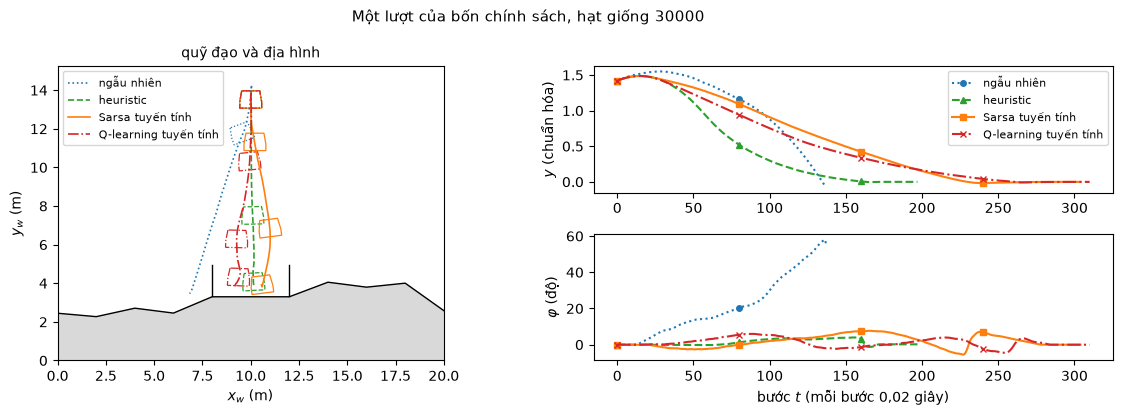

In [30]:
names4 = ["ngẫu nhiên", "heuristic", "Sarsa tuyến tính", "Q-learning tuyến tính"]
VIZ_SEED = TEST_SEED                                              # lượt đầu của tập đánh giá cuối
episodes4 = {name: run_episode(eval_env, final_policies[name], VIZ_SEED, keep_terrain=True) for name in names4}
for name, ep in episodes4.items():
    assert len(ep["actions"]) == final[name]["length"][0]         # trùng lượt trong đánh giá cuối
    print(f"{name:<22} hạt giống {VIZ_SEED}: {len(ep['actions'])} bước, {outcome(ep)}, "
          f"tổng thưởng {ep['rewards'].sum():.1f}")
plot_episodes(episodes4, STYLES, f"Một lượt của bốn chính sách, hạt giống {VIZ_SEED}", every=80)

In [31]:
display(HTML(lander_player(episodes4)))

Trình phát: 4 lượt, dài nhất 310 bước; HTML nhúng 38 kB


### 13.2. Giá trị hành động ước lượng so với lợi tức thực tế

**Vấn đề.** $\hat q$ được học từ mục tiêu bootstrap, nên cần kiểm xem nó dự đoán lợi tức tốt tới đâu. Dọc một lượt của chính sách tham lam, đặt $\max_a\hat q(S_t,a,w)$ cạnh lợi tức chiết khấu thực tế $G_t$.

**Hai đại lượng không cùng đích.** Bảng trọng số Sarsa được học từ dữ liệu của chính sách hành vi $\varepsilon$-tham lam, nên $\max_a\hat q(s,a,w)$ xấp xỉ giá trị khi chọn hành động tham lam rồi tiếp tục theo chính sách hành vi, chứ không phải giá trị của chính sách tham lam $\pi_w$. Mục tiêu của Q-learning dùng phép cực đại, nhắm tới $q_*$; với xấp xỉ hàm không có bảo đảm về điểm dừng (mục 14), và $\max_a\hat q$ cũng không phải giá trị của $\pi_w$. Ngoài ra $\hat q$ chỉ là phần tử của lớp tuyến tính, nên còn sai số xấp xỉ. Ô mã in trung bình trên $100$ lượt `TEST_SEED` của $\max_a\hat q(S_0,a,w)$ và $G_0$ kèm khoảng $\pm1{,}96\,\mathrm{SE}$ của hiệu ghép cặp, rồi vẽ hai đại lượng dọc lượt minh họa; trình phát hiển thị cùng các số này theo từng bước.

Sarsa tuyến tính       100 lượt TEST_SEED: TB max_a q_hat(S_0, a) =   33.3, TB G_0 =   41.2, hiệu   -7.9 ±  3.2
Q-learning tuyến tính  100 lượt TEST_SEED: TB max_a q_hat(S_0, a) =   60.2, TB G_0 =   47.7, hiệu   12.4 ±  2.2


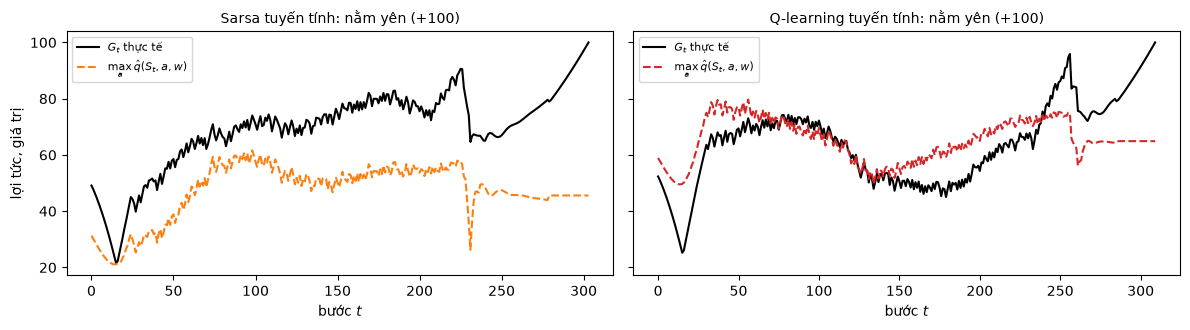

Trình phát: 2 lượt, dài nhất 310 bước; HTML nhúng 35 kB


In [32]:
info = {"G_t": {}, "max q_hat": {}}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, name, color in zip(axes, ["Sarsa tuyến tính", "Q-learning tuyến tính"], ["C1", "C3"]):
    Q = trained[name]["Q"]
    pred0 = np.array([Q.q(phi3(e["obs"][0])).max() for e in final[name]["episodes"]])   # max_a q_hat(S_0, a), (100,)
    d = pred0 - final[name]["G0"]
    print(f"{name:<22} 100 lượt TEST_SEED: TB max_a q_hat(S_0, a) = {pred0.mean():6.1f}, TB G_0 = "
          f"{final[name]['G0'].mean():6.1f}, hiệu {d.mean():6.1f} ± {1.96 * d.std(ddof=1) / np.sqrt(len(d)):4.1f}")
    ep = episodes4[name]
    pred = np.array([Q.q(f_).max() for f_ in phi3(ep["obs"][:-1])])   # max_a q_hat(S_t, a, w), cỡ (T,)
    G = returns(ep["rewards"], GAMMA)                              # G_t, cỡ (T,)
    ax.plot(G, color="k", lw=1.5, label="$G_t$ thực tế")
    ax.plot(pred, ls="--", color=color, label=r"$\max_a \hat q(S_t,a,w)$")
    ax.set_title(f"{name}: {outcome(ep)}", fontsize=10); ax.set_xlabel("bước $t$"); ax.legend(fontsize=8)
    for key, arr in [("G_t", G), ("max q_hat", pred)]:
        info[key][name] = np.append(arr, arr[-1])                  # thêm phần tử cho khung cuối T
axes[0].set_ylabel("lợi tức, giá trị")
plt.tight_layout(); plt.show()
display(HTML(lander_player({k: episodes4[k] for k in ["Sarsa tuyến tính", "Q-learning tuyến tính"]}, info=info)))

**Đọc kết quả.** Trên $100$ lượt, $\max_a\hat q(S_0,a,w)$ của Sarsa thấp hơn $G_0$ của chính sách tham lam ($-7{,}9\pm3{,}2$), còn của Q-learning cao hơn ($+12{,}4\pm2{,}2$). Hai chiều này phù hợp với hai đích khác nhau: Sarsa ước lượng giá trị khi tiếp tục theo chính sách hành vi có $\varepsilon=0{,}05$, có thể thấp hơn giá trị của chính sách tham lam (trong lần chạy này: $-7{,}9\pm3{,}2$); mục tiêu Q-learning lấy cực đại trên các ước lượng có nhiễu, có xu hướng đánh giá cao (nhiệm vụ 1 ở phần 16). Sai số xấp xỉ của lớp tuyến tính cũng góp vào cả hai chênh lệch; notebook chưa tách được phần của từng nguồn. Thực hành Bài 06 dạng bảng cho cùng hai chiều (Sarsa đánh giá thấp, Q-learning đánh giá cao).

### 13.3. Chuẩn của vector trọng số

Một dấu hiệu dễ đo của bất ổn là $\lVert w\rVert$ tăng không giới hạn. Hình dưới vẽ $\lVert w\rVert$ sau mỗi lượt huấn luyện của hai thuật toán.

Sarsa tuyến tính       ||w|| tại lượt 500, 1500, 3000: 35.7, 39.9, 46.5; lớn nhất 46.6
Q-learning tuyến tính  ||w|| tại lượt 500, 1500, 3000: 42.3, 45.8, 52.2; lớn nhất 52.5


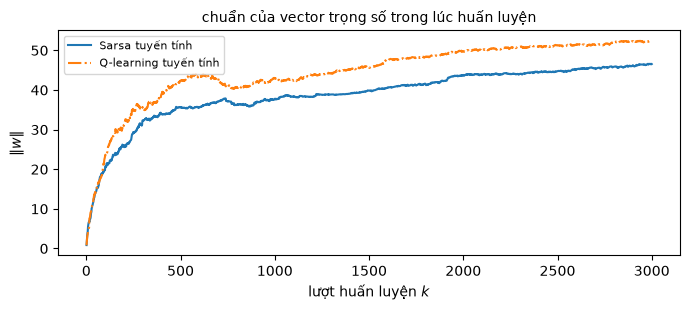

In [33]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for (name, out), ls in zip(trained.items(), ["-", "-."]):
    wn = out["log"]["wnorm"]                                          # ||w|| sau mỗi lượt, cỡ (N_TRAIN,)
    ax.plot(np.arange(1, N_TRAIN + 1), wn, ls=ls, label=name)
    print(f"{name:<22} ||w|| tại lượt 500, 1500, 3000: {wn[499]:.1f}, {wn[1499]:.1f}, {wn[-1]:.1f}; lớn nhất {wn.max():.1f}")
ax.set_xlabel("lượt huấn luyện $k$"); ax.set_ylabel(r"$\|w\|$"); ax.legend(fontsize=8)
ax.set_title("chuẩn của vector trọng số trong lúc huấn luyện", fontsize=10)
plt.tight_layout(); plt.show()

**Đọc hình.** Trong lần chạy này $\lVert w\rVert$ của cả hai thuật toán tăng chậm (Sarsa từ $35{,}7$ ở lượt $500$ lên $46{,}5$ ở lượt $3000$; Q-learning từ $42{,}3$ lên $52{,}2$), giá trị lớn nhất gần giá trị cuối và không có bước nhảy. Không thấy phân kỳ trong $3000$ lượt, nhưng một đường bị chặn trong khoảng hữu hạn không chứng minh hội tụ. Đánh giá định kỳ ở mục 12.1 vẫn có điểm rất thấp trong khi $\lVert w\rVert$ không tăng vọt: chất lượng chính sách tham lam có thể đổi mạnh khi thứ tự của bốn giá trị $\hat q$ đổi ở một vùng trạng thái, dù trọng số chỉ đổi ít.

## 14. Đối chiếu với phạm vi lý thuyết

Ghi chú Bài 07 (mục 10.4, 12.5, 13.2 và 14.1) tách ba trường hợp:

- **TD(0) tuyến tính theo chính sách cố định** (phần A): có bảo đảm hội tụ tới điểm cố định Bellman chiếu khi chính sách cố định, dữ liệu theo chính sách, chuỗi ergodic, $\gamma<1$, đặc trưng bị chặn, $\Phi$ đủ hạng cột và bước học thỏa Robbins–Monro (Tsitsiklis và Van Roy, 1997); với bài toán theo lượt, phân phối dừng được thay bằng phân phối ghé theo lượt (ghi chú, mục 10.4). Phần A dùng bước học hằng, không thỏa Robbins–Monro, và giả thiết trạng thái Markov trên quan sát chưa chắc đúng; nghiệm LSTD ở mục 8 là cách tính trực tiếp điểm cố định ước lượng từ dữ liệu.
- **Sarsa tuyến tính** (phần B): chính sách $\varepsilon$-tham lam đổi theo $w$, nên bảo đảm của TD tuyến tính không áp dụng; kết quả hội tụ cần giả thiết riêng về thăm dò, bước học và cách chính sách phụ thuộc $w$ (bài giảng gốc tr. 39; Zou, Xu và Liang, 2019, trong danh mục tài liệu ở tr. 45).
- **Q-learning tuyến tính** (phần B): có đủ ba yếu tố của bộ ba bất ổn, gồm mục tiêu bootstrap chứa $w$, dữ liệu do chính sách hành vi khác chính sách tham lam sinh ra, và xấp xỉ hàm. Theo bài giảng gốc (tr. 41), khi cả ba cùng có mặt, cập nhật có thể phân kỳ. Phát biểu này nói về khả năng phân kỳ trong một lớp thiết lập, chưa nói gì về một lần chạy cụ thể.

Cấu hình phần B dùng $\varepsilon_k$ dừng ở $0{,}05$ và bước học hằng: bước học hằng không thỏa Robbins–Monro, và giả thiết Markov trên quan sát chưa chắc đúng. Notebook vì vậy không khẳng định hội tụ; các số đo ở mục 12–13 chỉ mô tả lần chạy này.

**Đối chiếu với số đo.** Trong lần chạy này không có dấu hiệu phân kỳ của trọng số (mục 13.3). Các hiện tượng quan sát được là đánh giá định kỳ dao động mạnh (mục 12.1), biến thiên lớn giữa các hạt giống huấn luyện của cùng cấu hình (bảng `TUNE_CTRL`), và độ lệch có hệ thống của $\max_a\hat q$ so với lợi tức (mục 13.2). Đó là biểu hiện của việc học chưa ổn định, không phải bằng chứng phân kỳ.

**Câu hỏi:** (a) Chỉ ra từng yếu tố của bộ ba bất ổn trong hàm `train_linear` khi `algo="q"`, và yếu tố nào vắng mặt khi `algo="sarsa"`. (b) Trong bảng `TUNE_CTRL`, Fourier bậc 3 với $c=0{,}1$ cho Q-learning $230{,}2$; $25{,}2$; $234{,}0$ trên ba hạt giống. Giải thích vì sao một hạt giống tệ không chứng minh Q-learning tuyến tính phân kỳ, và cần đo thêm gì để phân biệt "phân kỳ" với "hội tụ tới chính sách kém".

<details><summary>Lời giải</summary>

(a) Bootstrap: mục tiêu `y = r + gamma * q2.max()` chứa $w$ qua `q2`. Khác chính sách: hành động được thực hiện do `epsilon_greedy_action(qv, eps, rng)` chọn, còn mục tiêu dùng cực đại, tức chính sách tham lam. Xấp xỉ hàm: $\hat q=x(s,a)^\top w$ với $w$ dùng chung qua lớp `LinearQ`. Với `algo="sarsa"`, mục tiêu dùng chính hành động `a2` lấy từ chính sách hành vi, nên yếu tố khác chính sách vắng mặt; hai yếu tố còn lại vẫn có, và chính sách vẫn đổi theo $w$.

(b) Phân kỳ là $\lVert w\rVert$ (hoặc dự đoán) tăng không giới hạn. Một tổng thưởng thấp cho biết chính sách tham lam ở lượt $3000$ kém, nhưng không cho biết $w$ có bị chặn hay không: $w$ có thể ổn định ở một điểm cho chính sách kém, hoặc dao động. Bảng `TUNE_WNORM` ở mục 12.3 cho $\lVert w\rVert$ lớn nhất $52{,}9$ và cuối $52{,}2$ ở chính hạt giống đó, cùng thang với hai hạt giống tốt, nên dữ liệu có được không cho thấy phân kỳ. Muốn phân biệt chắc hơn cần đo $\lVert w\rVert$ theo từng lượt (như mục 13.3), độ lệch giữa $\max_a\hat q$ và lợi tức thực tế, và lặp với nhiều hạt giống và nhiều thời điểm dừng.

</details>

## 15. Tổng kết

- **Dự đoán (phần A).** Trên cùng dữ liệu của Bài 05, hàm tuyến tính trên cơ sở Fourier bậc 3 cho sai số dự đoán lợi tức thấp hơn bảng $9216$ ô khi giải theo lô ($J=1481{,}0$ với MC theo lô so với $1626{,}8$), với $156$ trọng số thay cho $9216$ giá trị bảng. Trên cùng các lượt kết thúc thật, LSTD cho $J=1622{,}2$, cao hơn MC theo lô: $J$ đo khoảng cách tới lợi tức quan sát, là đích của MC theo lô, còn LSTD hướng tới điểm cố định Bellman chiếu. Với các họ đa thức và Fourier, phiên bản trực tuyến một lượt qua dữ liệu cho $J$ cao hơn nghiệm theo lô.
- **Điều khiển (phần B).** Sarsa và Q-learning tuyến tính trên cùng đặc trưng Fourier, không rời rạc hóa, đạt tổng thưởng $200{,}9$ và $205{,}3$ trên `TEST_SEED`, cao hơn nhiều bảng gốc của Bài 06 với cùng lịch học; heuristic vẫn cao hơn Q-learning tuyến tính trên $100$ lượt này.
- **Giới hạn.** Mỗi thuật toán chỉ có một lần huấn luyện trong notebook; cấu hình được chọn bằng thử nghiệm ngoài notebook nên có thiên lệch chọn; cấu hình phần B không thỏa các giả thiết của kết quả hội tụ, nên các số liệu chỉ mô tả lần chạy này.

In [34]:
print(f"Tổng thời gian chạy notebook: {time.time() - T_START:.0f} giây")

Tổng thời gian chạy notebook: 451 giây


## 16. Gợi mở tìm hiểu và cải tiến

Mỗi nhiệm vụ dưới nêu việc cần làm, gợi ý cách code và đại lượng cần đo. Một lần huấn luyện $3000$ lượt mất khoảng hai đến ba phút trên CPU khi soạn; khi so cấu hình, dùng ít nhất ba hạt giống huấn luyện, chọn cấu hình trên một tập hạt giống riêng (như mục 12.3) và chỉ báo kết quả cuối trên `TEST_SEED`.

1. **Double Q-learning tuyến tính.** Bảng `TUNE_CTRL` cho Q-learning một hạt giống chỉ đạt $25{,}2$ với $84\%$ lượt rơi, và mục 13.2 đo độ lệch giữa $\max_a\hat q(S_0,a,w)$ và $G_0$. Một nguồn gây lệch của mục tiêu Q-learning là phép cực đại trên các ước lượng có nhiễu: kỳ vọng của cực đại lớn hơn hoặc bằng cực đại của kỳ vọng, nên mục tiêu có xu hướng đánh giá cao (Sutton–Barto, ấn bản 2, §6.7). Double Q-learning (van Hasselt, 2010) giữ hai vector $w^{(1)}$, $w^{(2)}$; mỗi bước chọn ngẫu nhiên một vector để cập nhật, dùng chính nó để chọn hành động và vector kia để đánh giá:
$$Y=R+\gamma\,\hat q\bigl(S',\ \arg\max_{a}\hat q(S',a,w^{(1)}),\ w^{(2)}\bigr),\qquad w^{(1)}\leftarrow w^{(1)}+\alpha\bigl[Y-\hat q(S,A,w^{(1)})\bigr]x(S,A),$$
và đổi vai hai vector khi cập nhật $w^{(2)}$. Phép $\arg\max$ trong mục tiêu dùng cùng quy tắc đồng hạng chia đều như $\varepsilon$-tham lam. Hành vi là $\varepsilon$-tham lam theo $\hat q(\cdot,w^{(1)})+\hat q(\cdot,w^{(2)})$; chính sách tham lam cuối (`greedy_double`) cũng dùng tổng này, tương đương dùng trung bình $\tfrac12\bigl(\hat q(\cdot,w^{(1)})+\hat q(\cdot,w^{(2)})\bigr)$. Độ lệch so với $G_0$ đo bằng trung bình này, cùng thang với $\max_a\hat q$ ở mục 13.2. Hàm `double_q_linear` dưới chạy được (ô mã chỉ thử $3$ lượt), ghi $\lVert w^{(1)}\rVert$, $\lVert w^{(2)}\rVert$ theo lượt và nhận hàm đánh giá định kỳ tùy chọn như `train_linear`. Việc cần làm: huấn luyện $3000$ lượt với ba hạt giống (khoảng $10$ phút), so với Q-learning tuyến tính về tổng thưởng trên `TEST_SEED`, độ lệch $\max_a\tfrac12(\hat q_1+\hat q_2)(S_0,a)-G_0$ và $\lVert w\rVert$. Ý tưởng tách chọn và đánh giá được dùng lại trong Double DQN (biến thể của mạng Q sâu, Bài 08–09).
2. **Nhiều hạt giống cho cấu hình đã chọn.** Lặp mục 12 với `TRAIN_SEED` và `AGENT_SEED` khác, báo trung bình ± sd giữa các lần chạy trên `TEST_SEED`. Đo thêm $\lVert w\rVert$ theo lượt của lần chạy tệ nhất để phân biệt phân kỳ với hội tụ tới chính sách kém (câu hỏi mục 14).
3. **Chọn điểm dừng theo tập kiểm định.** Đường đánh giá định kỳ ở mục 12.1 dao động. Giữ bản sao $w$ có điểm kiểm định cao nhất (dùng nhiều lượt `VALID_SEED` hơn), rồi báo bản đó trên `TEST_SEED`; so với $w$ ở lượt $3000$.
4. **Họ đặc trưng khác.** Thử hàm cơ sở bán kính (RBF) trên $z$, Fourier bậc $4$, hoặc cho phép ba biến tương tác (`max_nonzero=3`); tile coding là một dạng mã hóa thô, gần với rời rạc hóa nhiều lớp chồng lệch nhau (Sutton–Barto §9.5.4). Ghi $p$, thời gian một lượt và tổng thưởng.
5. **Bước học.** Thử $c\in\{0{,}05;\,0{,}2\}$ và bước học giảm dần $\alpha_n=c/(\mathbb E\lVert x\rVert^2\cdot(1+n/n_0))$; với Fourier, Konidaris và cộng sự (2011) đề xuất bước học riêng $\alpha/\lVert c^{(i)}\rVert$ cho từng hàm cơ sở.
6. **Expected Sarsa tuyến tính.** Thay $\hat q(S',A',w)$ bằng $\sum_{a'}\pi_\varepsilon(a'\mid S')\,\hat q(S',a',w)$ (Sutton–Barto §6.6) và so độ biến thiên giữa các hạt giống với Sarsa.
7. **Đặc trưng thiết kế.** Thêm hai đặc trưng $a_{\text{góc}}$, $a_{\text{cao}}$ của bản tinh chỉnh Bài 06 vào $z$ trước khi tạo cơ sở Fourier; nêu rõ đây là kiến thức mượn từ hàm `heuristic`.
8. **Điều khiển theo lô.** Đọc phương pháp lặp chính sách bình phương tối thiểu (LSPI; Lagoudakis và Parr, 2003), dùng LSTD-Q thay cho LSTD của mục 8 để đánh giá chính sách tham lam trên dữ liệu đã thu, rồi cải thiện chính sách.
9. **Bất ổn khác chính sách.** Cài ví dụ Baird (Sutton–Barto §11.2) với TD bán gradient khác chính sách và vẽ $\lVert w\rVert$; đọc các phương pháp gradient TD (Sutton–Barto ch. 11) nhắm vào trường hợp này.
10. **Nhập nhằng do cắt biên.** Mục 12.1 ghi nhận một điểm đánh giá định kỳ rất thấp của Sarsa, khi tàu bay lên quá $y=1{,}6$. Nới `HI` của $y$ và $v_y$ (ví dụ $y$ tới $3$, $v_y$ tới $2$), hoặc thêm hai đặc trưng không bị cắt như $\tanh(y-1{,}6)$ và $\tanh(v_y)$ vào $\phi$, rồi đo lại tỉ lệ bước vượt biên, số điểm đánh giá định kỳ rất thấp và tổng thưởng trên `TEST_SEED` với ba hạt giống.
11. **Mạng nơ-ron.** Thay $\hat q$ tuyến tính bằng mạng nhiều lớp với bộ đệm phát lại và mạng mục tiêu: đây là mạng Q sâu (DQN) của Bài 08.

In [35]:
def greedy_double(Q1, Q2, phi):
    # chính sách tham lam theo q_hat(., w1) + q_hat(., w2), đồng hạng chia đều
    def policy(obs, rng):
        f = phi(obs)
        return epsilon_greedy_action(Q1.q(f) + Q2.q(f), 0.0, rng)
    return policy


def double_q_linear(phi, p, n_episodes, gamma, eps_fn, alpha, env_seed, agent_seed, eval_every=0, eval_fn=None):
    env_d = make_env()
    Q1, Q2 = LinearQ(p), LinearQ(p)
    rng = np.random.default_rng(agent_seed)
    log = {"total": [], "wnorm1": [], "wnorm2": []}; evals = []
    for k in range(n_episodes):
        eps = eps_fn(k)
        obs, _ = env_d.reset(seed=env_seed + k)
        f = phi(obs); total = 0.0
        while True:
            a = epsilon_greedy_action(Q1.q(f) + Q2.q(f), eps, rng)       # hành vi theo tổng hai ước lượng
            obs, r, terminated, truncated, _ = env_d.step(a)
            total += r; f2 = phi(obs)
            A_, B_ = (Q1, Q2) if rng.random() < 0.5 else (Q2, Q1)       # chọn ngẫu nhiên vector được cập nhật
            if terminated:
                y = r
            else:
                a_star = epsilon_greedy_action(A_.q(f2), 0.0, rng)       # chọn hành động bằng A_ (đồng hạng chia đều)
                y = r + gamma * B_.q(f2)[a_star]                         # đánh giá bằng B_
            A_.update(f, a, alpha * (y - A_.q(f)[a]))                    # chỉ A_ được cập nhật
            if terminated or truncated:
                break
            f = f2
        log["total"].append(total); log["wnorm1"].append(Q1.norm()); log["wnorm2"].append(Q2.norm())
        if eval_every and (k + 1) % eval_every == 0:
            evals.append((k + 1,) + eval_fn(greedy_double(Q1, Q2, phi)))
    return Q1, Q2, {key: np.array(v) for key, v in log.items()}, evals


Q1_, Q2_, log_, _ = double_q_linear(phi3, p3, 3, GAMMA, linear_epsilon, ALPHA, TRAIN_SEED, AGENT_SEED)
assert np.isfinite(log_["wnorm1"]).all() and np.isfinite(log_["wnorm2"]).all()
print("thử 3 lượt: tổng thưởng", log_["total"].round(1), "| ||w1||, ||w2|| cuối =",
      round(log_["wnorm1"][-1], 2), round(log_["wnorm2"][-1], 2))

thử 3 lượt: tổng thưởng [-130.8 -308.6 -148.8] | ||w1||, ||w2|| cuối = 1.29 1.14


### Tài liệu tham khảo

- Tạ Việt Cường, *Lecture 07: Hàm xấp xỉ trong Reinforcement Learning*, bài giảng gốc học kỳ 2 năm học 2025–2026: tr. 24–26 (lớp hàm tuyến tính và các lớp khác), tr. 28–31 (đặc trưng, ví dụ Lunar Lander tr. 29, mã hóa cặp trạng thái–hành động tr. 31), tr. 33 (hồi quy), tr. 32–37 (bán gradient, MC và TD với xấp xỉ hàm), tr. 38–41 (điều khiển, bộ ba bất ổn), tr. 42–45 (kết quả lý thuyết, hạn chế, tài liệu tham khảo).
- Ghi chú Bài 07 của học phần: mục 4–5 (lớp tuyến tính, đặc trưng), 7–10 (MC, TD(0), điểm cố định Bellman chiếu), 12–14 (điều khiển, bộ ba bất ổn, phạm vi lý thuyết).
- R. S. Sutton, A. G. Barto, *Reinforcement Learning: An Introduction*, ấn bản 2, MIT Press, 2018: §6.6–6.7, §9.3–9.6, §9.8, §10.1, §11.2–11.3.
- J. N. Tsitsiklis, B. Van Roy, "An analysis of temporal-difference learning with function approximation", *IEEE Transactions on Automatic Control* 42(5), 1997, 674–690.
- G. Konidaris, S. Osentoski, P. Thomas, "Value function approximation in reinforcement learning using the Fourier basis", *AAAI*, 2011.
- H. van Hasselt, "Double Q-learning", *Advances in Neural Information Processing Systems* 23, 2010.
- M. G. Lagoudakis, R. Parr, "Least-squares policy iteration", *Journal of Machine Learning Research* 4, 2003, 1107–1149.
- Tài liệu `LunarLander-v3` và mã nguồn `gymnasium.envs.box2d.lunar_lander` (Gymnasium 1.x).